# Notebook 08: EDA Contextual e Screening de Covariáveis

Caracteriza as camadas de contexto BHMap e testa a viabilidade das variáveis contextuais para as análises de segmentação. Reúne duas frentes: a comparação de GCI_empírico vs GCI_original por regional e o screening de covariáveis a partir de `cnefe_master_metrics.parquet` (disponível após o ETL `enrich_master_metrics.py`), e a EDA detalhada das camadas BHMap (edificação, área de risco, IVS, lotes CTM e cadastro imobiliário), realocada do NB03 para consolidar todo o contexto urbano em um único notebook.

**O que este notebook cobre:**
- Síntese multivariada por regional e triagem KW/Spearman das covariáveis sobre o GCI_empírico
- Sanidade geométrica, distribuições e cobertura espacial de cada camada de contexto
- Alinhamento das variáveis contextuais com as hipóteses de pesquisa

**Hipóteses preparadas:** a triagem identifica quais variáveis contextuais predizem GCI_empírico, insumo direto para NB09 a NB12.

In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

metrics = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
metrics['especie_label'] = metrics['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')
metrics['tipo_label']    = metrics['COD_TIPO_ESPECI'].map(config.TIPO_ESPECIE_MAP).fillna('N/A')
metrics['nv_label']      = metrics['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')

print(f'Métricas: {len(metrics):,} registros | {metrics.shape[1]} colunas')

Métricas: 1,172,902 registros | 119 colunas


> **GCI por regional:** Ver NB07 Seção 1.2 para comparação GCI_original vs GCI_empírico por regional (análise formal com teste estatístico).

## 1. Síntese Multivariada por Regional

A tabela reúne N, proporção NV=1, LCI médio, MCI médio, GCI_original mediano, GCI_empírico mediano, CCR, DRS mediana e CDI mediano por regional. O objetivo é verificar se regionais com CDI mediano alto também apresentam CCR baixo, o que fortaleceria a validade do CDI como proxy de qualidade posicional.

In [2]:

# Tabela síntese por regional
if 'NOME_REGIO' in metrics.columns:
    tabela = metrics.groupby('NOME_REGIO').agg(
        N=('LCI', 'count'),
        pct_NV1=('NV_GEO_COORD', lambda x: (x == 1).mean() * 100),
        LCI_medio=('LCI', 'mean'),
        MCI_medio=('MCI', 'mean'),
        GCI_orig_medio=('GCI_original', 'median'),
        GCI_emp_medio=('GCI_empirico', 'median'),
        CCR_pct=('ccr', lambda x: x.mean() * 100),
        DRS_mediana=('drs', 'median'),
        CDI_mediano=('cdi', 'median'),
    ).round(3)

    display(tabela.style
        .background_gradient(subset=['GCI_emp_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['GCI_orig_medio'], cmap='RdYlGn', vmin=0, vmax=1)
        .background_gradient(subset=['CDI_mediano'], cmap='OrRd')
        .background_gradient(subset=['CCR_pct'], cmap='RdYlGn')
        .format({'N': '{:,.0f}', 'pct_NV1': '{:.1f}%', 'LCI_medio': '{:.3f}',
                 'MCI_medio': '{:.3f}', 'GCI_orig_medio': '{:.3f}', 'GCI_emp_medio': '{:.3f}',
                 'CCR_pct': '{:.1f}%', 'DRS_mediana': '{:.1f}', 'CDI_mediano': '{:.1f}'})
        .set_caption('Síntese por regional — métricas GCI v2'))

    tabela.to_csv(config.TAB_DIR / 'nb08_descritivas_por_regional.csv')
    print("Salvo: descritivas_por_regional_v2.csv")

,N,pct_NV1,LCI_medio,MCI_medio,GCI_orig_medio,GCI_emp_medio,CCR_pct,DRS_mediana,CDI_mediano
NOME_REGIO,,,,,,,,,
BARREIRO,"132,325",92.7%,0.984,0.810,0.834,0.575,75.9%,4.6,1.0
CENTRO-SUL,"135,835",80.2%,0.955,0.795,0.420,0.593,76.0%,4.6,1.0
HIPERCENTRO,"21,404",85.5%,0.944,0.765,0.403,0.559,75.8%,4.5,1.0
LESTE,"111,005",83.5%,0.966,0.800,0.778,0.577,75.9%,4.6,1.0
NORDESTE,"145,064",86.4%,0.970,0.806,0.794,0.574,76.0%,4.6,1.0
NOROESTE,"127,140",81.4%,0.957,0.802,0.777,0.557,76.0%,4.6,1.0
NORTE,"100,884",90.6%,0.975,0.804,0.828,0.567,75.9%,4.7,1.0
OESTE,"155,121",79.8%,0.957,0.800,0.452,0.588,75.9%,4.7,1.0
PAMPULHA,"123,924",77.2%,0.951,0.806,0.564,0.557,75.5%,4.6,1.0


Salvo: descritivas_por_regional_v2.csv


---
### Síntese: leitura da tabela regional

A tabela confirma o padrão multivariado esperado: **regionais com CDI mediano mais alto (Hipercentro, Centro-Sul) apresentam simultaneamente GCI_empírico mais baixo e diferença maior em relação ao GCI_original**, evidência direta de que o CDI captura uma dimensão real de incerteza posicional que o PCI arbitrário original sub-representava para apartamentos. O CCR e o DRS mediano completam o quadro: onde a densidade de coordenadas compartilhadas é maior, a taxa de acerto posicional tende a ser menor, sustentando a hipótese de que CDI é um proxy válido para qualidade posicional sem necessidade de ground truth externo.

A tabela acima registra os valores definitivos por regional. O arquivo `descritivas_por_regional_v2.csv` fica disponível em `outputs/tables/` para importação direta no documento LaTeX.

---
## 2. Variáveis Contextuais BHMap: Cobertura, Distribuições e Viabilidade das Hipóteses

O enriquecimento contextual (`cnefe_master_metrics.parquet`) incorpora 13 camadas BHMap: hierarquia viária, declividade, altitude, zoneamento, atividade econômica, setor censitário, vila/favela, lotes cadastrais, edificações e áreas de risco (~100 colunas no total). Esta seção valida cobertura, mostra distribuições e apresenta associações preliminares KW/Spearman com GCI_empírico, que servem de triagem para H5 e H7.

**Pré-requisito:** `cnefe_master_metrics.parquet`, disponível após execução do pipeline ETL.

In [3]:

v3_path = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'

if not v3_path.exists():
    print("cnefe_master_metrics.parquet nao encontrado.")
    m3 = None
else:
    m3 = metrics  # alias: evita carga duplicada do mesmo parquet
    print(f"cnefe_master_metrics: {len(m3):,} registros x {m3.shape[1]} colunas")

    # Tabela de cobertura de todas as colunas
    cov = pd.DataFrame({
        'coluna':        m3.columns.tolist(),
        'dtype':         m3.dtypes.astype(str).tolist(),
        'n_nao_nulo':    m3.notna().sum().tolist(),
        'pct_cobertura': (m3.notna().mean() * 100).round(1).tolist(),
    }).sort_values('pct_cobertura', ascending=False)

    n_alta = (cov['pct_cobertura'] >= 80).sum()
    print(f"Colunas com cobertura >= 80%: {n_alta}/{len(cov)}")
    print(f"Colunas com cobertura < 50%:  {(cov['pct_cobertura'] < 50).sum()}/{len(cov)}")

    display(cov.style
        .background_gradient(subset=['pct_cobertura'], cmap='RdYlGn', vmin=0, vmax=100)
        .format({'n_nao_nulo': '{:,.0f}', 'pct_cobertura': '{:.1f}%'})
        .set_caption('Cobertura de variaveis — cnefe_master_metrics (ordenado por cobertura descrescente)'))

cnefe_master_metrics: 1,172,902 registros x 119 colunas


Colunas com cobertura >= 80%: 85/119
Colunas com cobertura < 50%:  33/119


,coluna,dtype,n_nao_nulo,pct_cobertura
0,idx_cnefe_original,int64,"1,172,902",100.0%
1,COD_UNICO_ENDERECO,str,"1,172,902",100.0%
2,COD_ESPECIE,int64,"1,172,902",100.0%
4,COD_SETOR,str,"1,172,902",100.0%
5,CEP,str,"1,172,902",100.0%
6,DSC_LOCALIDADE,str,"1,172,902",100.0%
7,LOGRAD_NUM,str,"1,172,902",100.0%
21,bhmap_geom,geometry,"1,172,902",100.0%
8,COMPLEMENTO,str,"1,172,902",100.0%
9,NV_GEO_COORD,int32,"1,172,902",100.0%


### 2.1 Cobertura das Variáveis Contextuais

A tabela de cobertura confirma que as camadas-chave do BHMap têm alta cobertura (≥ 80%) no dataset: VIA_CLASSIFICA, DECLIV_CLASSE, ZONA_TIPO, TIPO_ASSENTAMENTO e ALTITUDE_CLASSE estão disponíveis para praticamente todos os registros. Variáveis de menor cobertura (como flags de infraestrutura por lote) são tratadas com valores padrão ou excluídas das análises que exigem completude total.

**Distribuições das variáveis de segmentação.**

Os histogramas e gráficos de barras a seguir mostram a distribuição empírica de cada variável contextual, permitindo verificar desequilíbrios de classes (estratos muito pequenos) antes de aplicar testes Kruskal-Wallis nas seções seguintes.

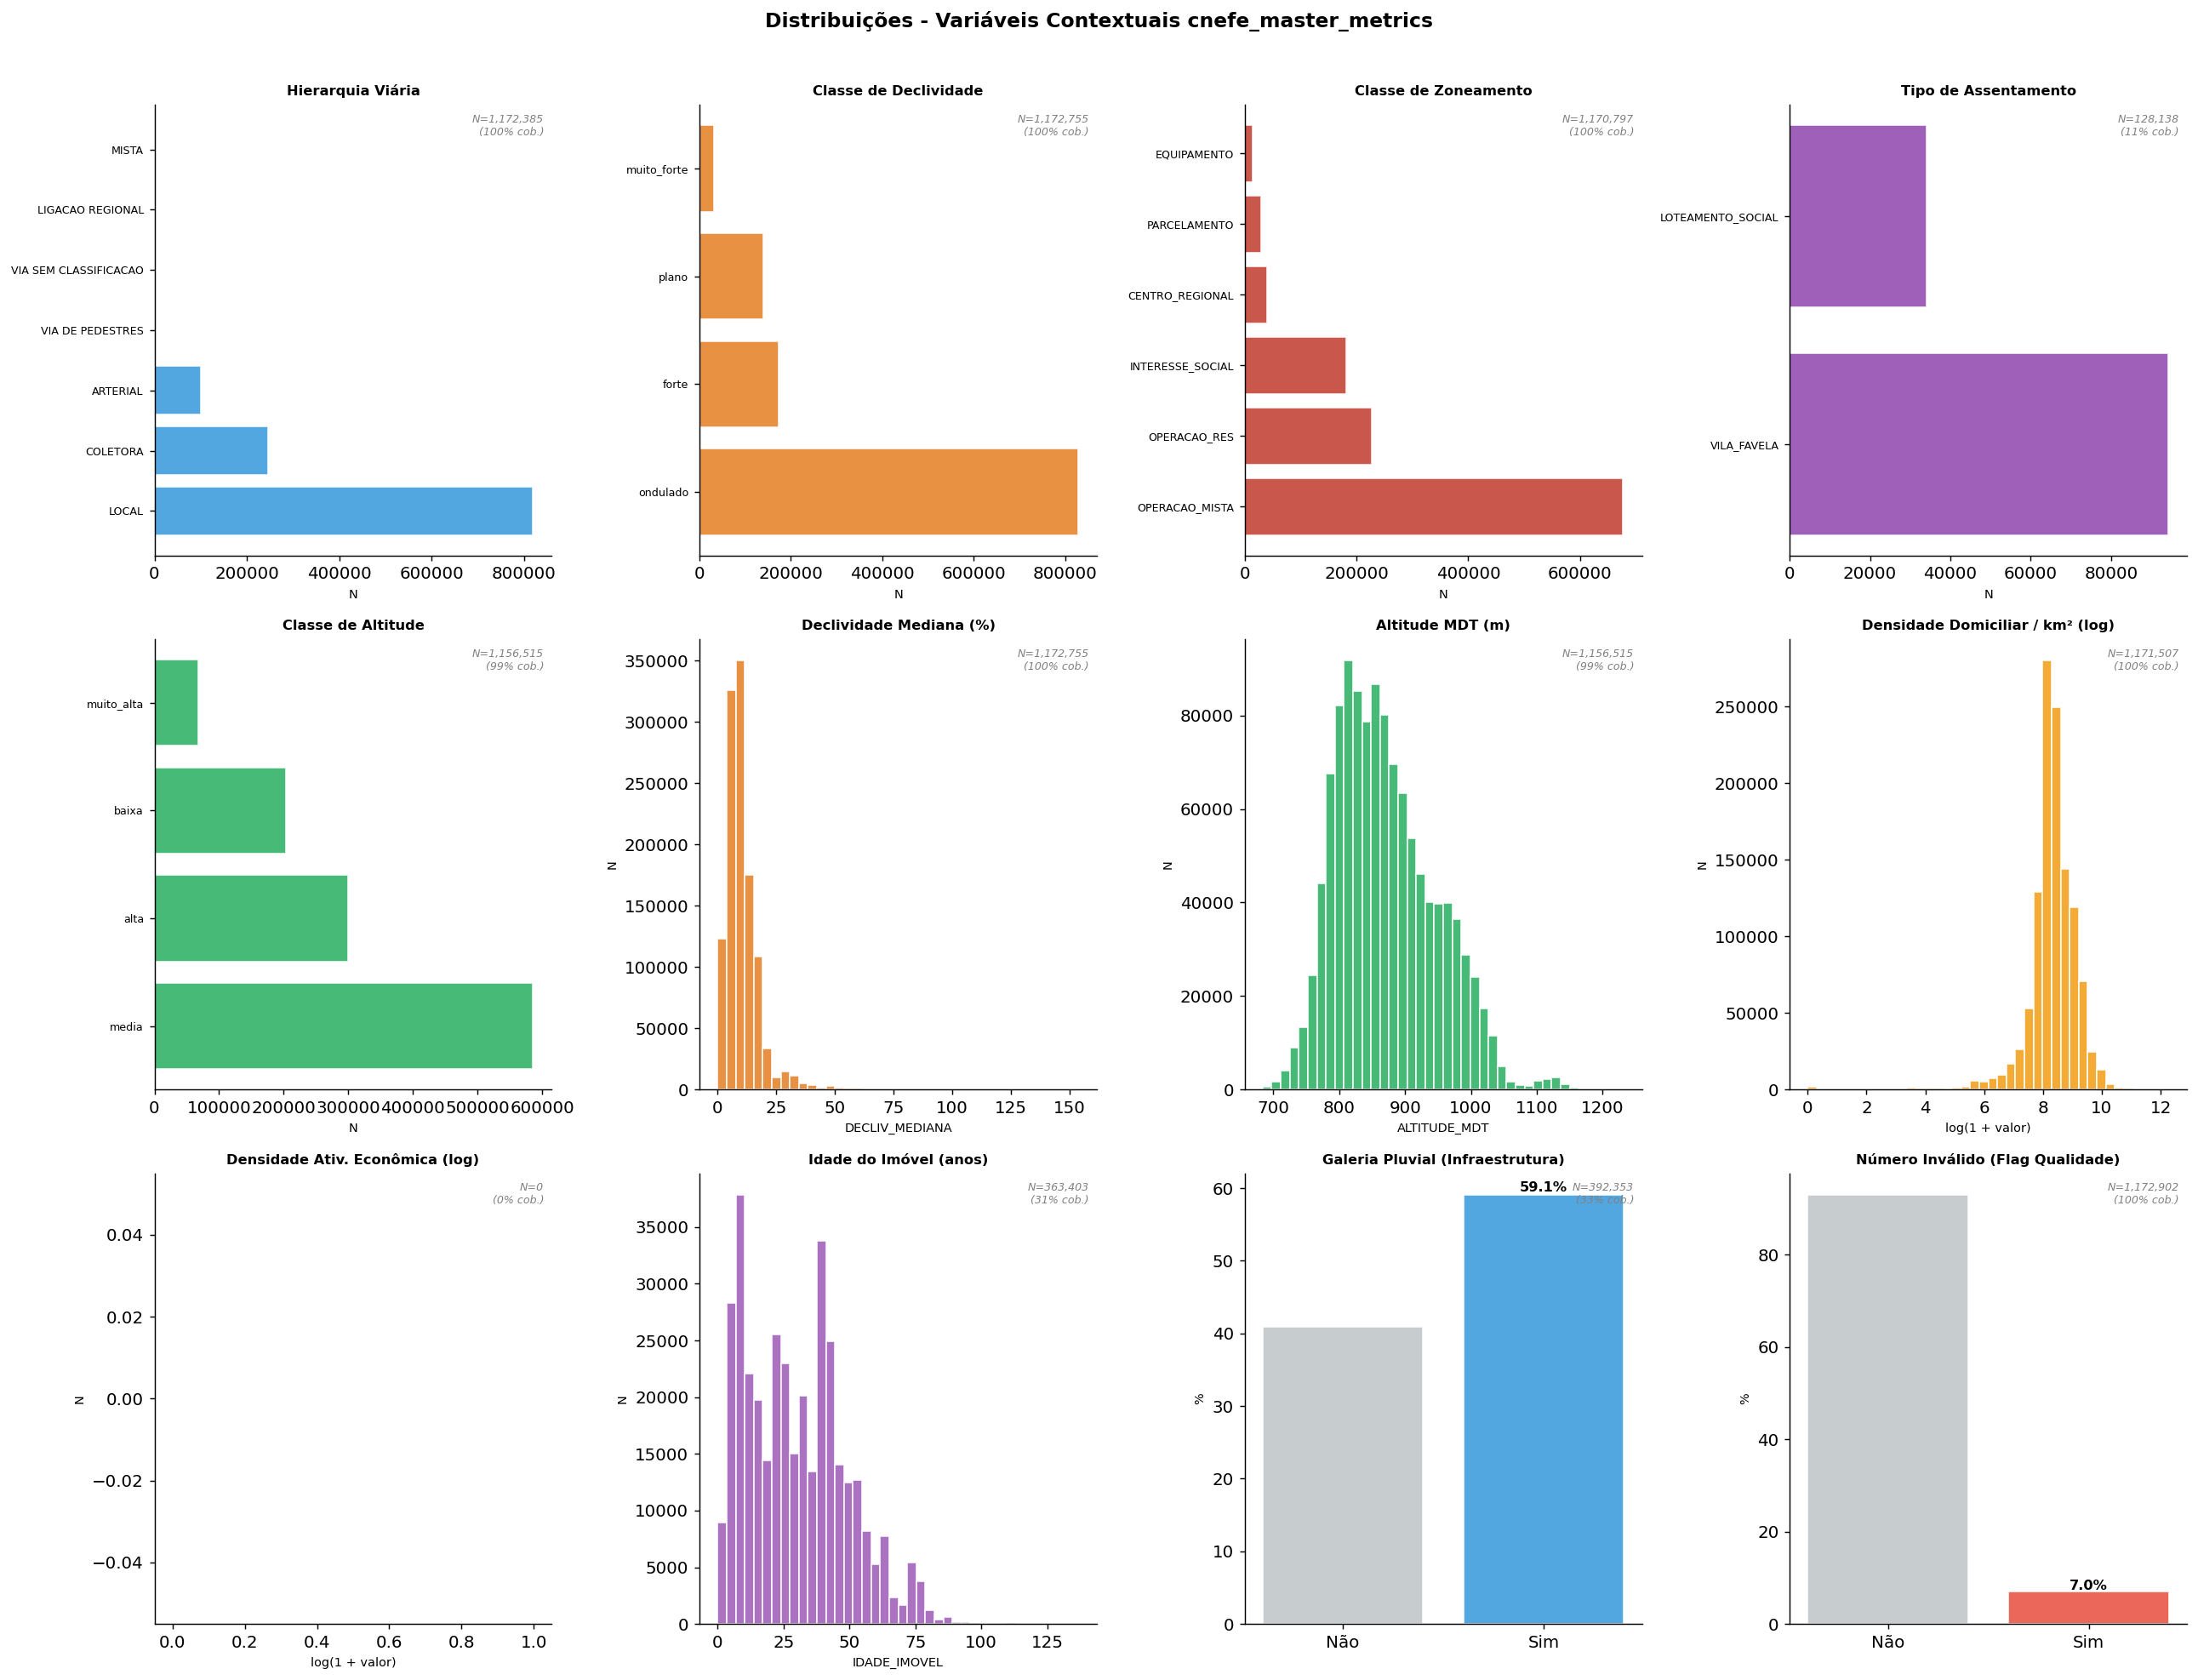

In [4]:
if m3 is None:
    print("Pulando: cnefe_master_metrics.parquet não disponível.")
else:
    PLOT_VARS = [
        ('VIA_CLASSIFICA',     'bar',     'Hierarquia Viária',              '#3498db'),
        ('DECLIV_CLASSE',      'bar',     'Classe de Declividade',          '#e67e22'),
        ('ZONA_CLASSE',        'bar',     'Classe de Zoneamento',           '#c0392b'),
        ('TIPO_ASSENTAMENTO',  'bar',     'Tipo de Assentamento',           '#8e44ad'),
        ('ALTITUDE_CLASSE',    'bar',     'Classe de Altitude',             '#27ae60'),
        ('DECLIV_MEDIANA',     'hist',    'Declividade Mediana (%)',         '#e67e22'),
        ('ALTITUDE_MDT',       'hist',    'Altitude MDT (m)',               '#27ae60'),
        ('DENS_DOM_KM2',       'loghist', 'Densidade Domiciliar / km² (log)','#f39c12'),
        ('DENS_ATIV_ECON_KM2', 'loghist', 'Densidade Ativ. Econômica (log)', '#1abc9c'),
        ('IDADE_IMOVEL',       'hist',    'Idade do Imóvel (anos)',          '#9b59b6'),
        ('IND_GALERIA_PLUVIAL','bool',    'Galeria Pluvial (Infraestrutura)','#3498db'),
        ('FLAG_NUMERO_INVALIDO','bool',   'Número Inválido (Flag Qualidade)','#e74c3c'),
    ]

    avail = [(v, k, t, c) for v, k, t, c in PLOT_VARS if v in m3.columns]
    ncols = 4
    nrows = -(-len(avail) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
    axes = axes.flatten()

    for i, (col, kind, title, color) in enumerate(avail):
        ax = axes[i]
        data = m3[col].dropna()
        ax.set_title(title, fontweight='bold', fontsize=9)
        n_valid = len(data)
        pct_valid = n_valid / len(m3) * 100

        if kind == 'bar':
            vc = data.value_counts().head(10)
            ax.barh(range(len(vc)), vc.values, color=color, alpha=0.85, edgecolor='white')
            ax.set_yticks(range(len(vc)))
            ax.set_yticklabels(vc.index.astype(str), fontsize=7)
            ax.set_xlabel('N', fontsize=8)
        elif kind == 'hist':
            ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='white')
            ax.set_xlabel(col, fontsize=8)
            ax.set_ylabel('N', fontsize=8)
        elif kind == 'loghist':
            ax.hist(np.log1p(data), bins=40, color=color, alpha=0.85, edgecolor='white')
            ax.set_xlabel('log(1 + valor)', fontsize=8)
            ax.set_ylabel('N', fontsize=8)
        elif kind == 'bool':
            pct_true = data.mean() * 100
            ax.bar(['Não', 'Sim'], [100 - pct_true, pct_true],
                   color=['#bdc3c7', color], alpha=0.85, edgecolor='white')
            ax.set_ylabel('%', fontsize=8)
            ax.text(1, pct_true + 0.5, f'{pct_true:.1f}%', ha='center', fontsize=9, fontweight='bold')

        ax.text(0.98, 0.98, f'N={n_valid:,}\n({pct_valid:.0f}% cob.)',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=7, color='gray', style='italic')

    for ax in axes[len(avail):]:
        ax.set_visible(False)

    plt.suptitle('Distribuições - Variáveis Contextuais cnefe_master_metrics',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb08_distribuicoes.png', bbox_inches='tight', dpi=130)
    plt.show()

### 2.2 Distribuições das Variáveis Contextuais

Os gráficos mostram a distribuição de cada variável contextual com cobertura e N indicados. Classes dominantes indicam potencial desequilíbrio para testes KW, por exemplo, VIA_CLASSIFICA com poucos registros em "Ligação Regional" limita o poder estatístico nessa categoria. DENS_ATIV_ECON_KM2 e DENS_DOM_KM2 em escala log evidenciam distribuições lognormais, consistentes com a literatura de distribuição urbana. As seções 9 e 10 verificam formalmente a viabilidade dos testes por estrato.

---
### 2.3 Volume por Estrato: Suporte Estatístico às Hipóteses

Antes de aplicar Kruskal-Wallis, é necessário verificar que cada estrato tenha N ≥ 30, limiar convencional para validade assintótica do teste. Com ~1,18M registros, mesmo estratos minoritários tendem a superar esse limite, mas a verificação explícita é necessária para segmentações com categorias raras.

Variáveis com `Viável_KW = False` são excluídas das análises dos NB09–NB12 ou tratadas com agrupamento de categorias raras.

Segmentações viáveis para Kruskal-Wallis (N_min ≥ 30, ≥ 2 grupos): 18/18


,Variável,Hipótese,Disponível,N_total,N_grupos,N_min,N_max,Cobertura_%,Viável_KW
0,VIA_CLASSIFICA,Hierarquia Viária (H5),True,"1,172,385",7,47,"819,249",100.0%,True
1,DECLIV_CLASSE,Declividade — classe (H6),True,"1,172,755",4,"31,675","827,864",100.0%,True
2,ZONA_CLASSE,Classe de Zoneamento,True,"1,170,797",6,"14,836","676,730",99.8%,True
3,FLAG_ZONA_SOCIAL,Zona Social (AEIS/ZEIS),True,"1,170,797",2,"182,258","988,539",99.8%,True
4,TIPO_ASSENTAMENTO,Tipo de Assentamento,True,"128,138",2,"33,961","94,177",10.9%,True
5,TEM_PLANO_URBANO,Plano Urbano,True,"128,138",3,"1,751","90,095",10.9%,True
6,IND_GALERIA_PLUVIAL,Galeria Pluvial,True,"392,353",2,"160,457","231,896",33.5%,True
7,IND_PAVIMENTACAO,Pavimentação,True,"392,353",2,"14,050","378,303",33.5%,True
8,IND_REDE_ESGOTO,Rede de Esgoto,True,"392,353",2,"17,557","374,796",33.5%,True
9,FLAG_ESTABELECIMENTO,Estabelecimento (Esp. 6/7),True,"1,172,902",2,"143,792","1,029,110",100.0%,True


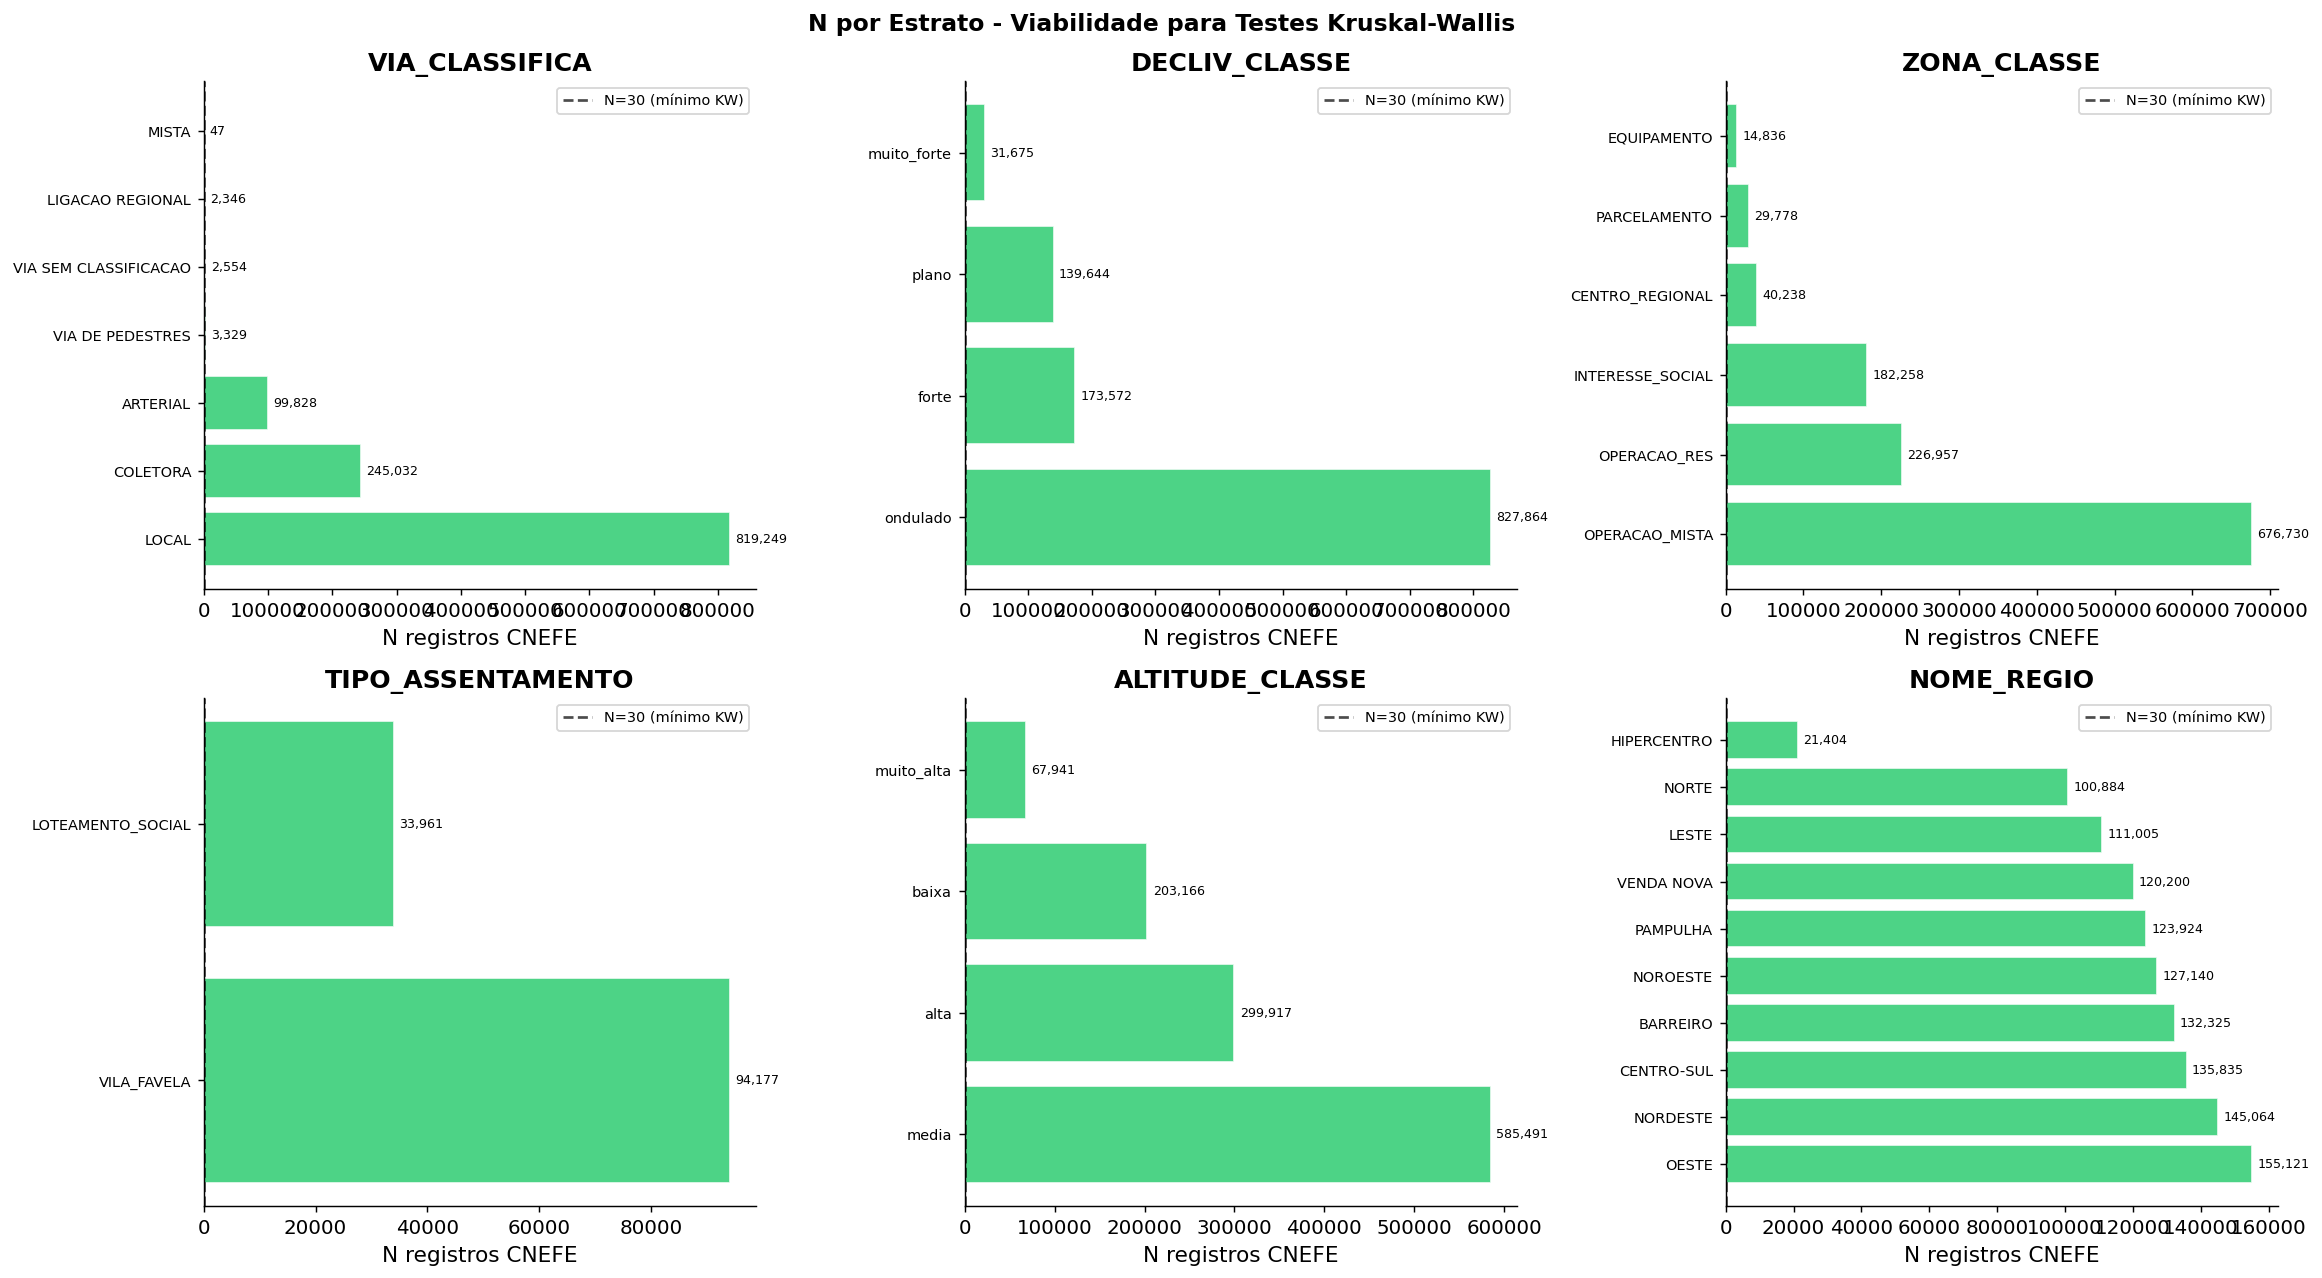

In [5]:
if m3 is None:
    print("Pulando: cnefe_master_metrics.parquet não disponível.")
else:

    SEG_VARS = {
        'VIA_CLASSIFICA':      'Hierarquia Viária (H5)',
        'DECLIV_CLASSE':       'Declividade — classe (H6)',
        'ZONA_CLASSE':         'Classe de Zoneamento',
        'FLAG_ZONA_SOCIAL':    'Zona Social (AEIS/ZEIS)',
        'TIPO_ASSENTAMENTO':   'Tipo de Assentamento',
        'TEM_PLANO_URBANO':    'Plano Urbano',
        'IND_GALERIA_PLUVIAL': 'Galeria Pluvial',
        'IND_PAVIMENTACAO':    'Pavimentação',
        'IND_REDE_ESGOTO':     'Rede de Esgoto',
        'FLAG_ESTABELECIMENTO':'Estabelecimento (Esp. 6/7)',
        'FLAG_NUMERO_INVALIDO':'Número Inválido (Contaminação)',
        'em_favela':           'Em Vila/Favela',
        'em_inundacao':        'Área de Inundação',
        'em_escorregamento':   'Área de Escorregamento',
        'ALTITUDE_CLASSE':     'Classe de Altitude',
        'VIA_HIERARQUIA':      'VIA_HIERARQUIA (ordinal)',
        'especie_label':       'Espécie CNEFE',
        'NOME_REGIO':          'Regional Administrativa',
    }

    rows = []
    for col, desc in SEG_VARS.items():
        if col not in m3.columns:
            rows.append({'Variável': col, 'Hipótese': desc, 'Disponível': False,
                         'N_total': 0, 'N_grupos': 0, 'N_min': 0, 'N_max': 0,
                         'Cobertura_%': 0.0, 'Viável_KW': False})
            continue
        col_data = m3[col]
        n_total = int(col_data.notna().sum())
        vc = col_data.value_counts()
        rows.append({
            'Variável': col, 'Hipótese': desc, 'Disponível': True,
            'N_total': n_total, 'N_grupos': len(vc),
            'N_min': int(vc.min()), 'N_max': int(vc.max()),
            'Cobertura_%': n_total / len(m3) * 100,
            'Viável_KW': n_total >= 100 and len(vc) >= 2 and vc.min() >= 30,
        })

    viab_df = pd.DataFrame(rows)
    n_viavel = viab_df['Viável_KW'].sum()
    print(f"Segmentações viáveis para Kruskal-Wallis (N_min ≥ 30, ≥ 2 grupos): "
          f"{n_viavel}/{len(viab_df)}")

    def row_color(row):
        if not row['Disponível']:
            return [''] * len(row)
        return ['background-color: #d5f5e3' if row['Viável_KW']
                else 'background-color: #fdedec'] * len(row)

    display(viab_df.style
        .apply(row_color, axis=1)
        .format({'N_total': '{:,.0f}', 'N_min': '{:,.0f}',
                 'N_max': '{:,.0f}', 'Cobertura_%': '{:.1f}%'})
        .set_caption('Viabilidade das segmentações para testes KW '
                     '(verde = viável, vermelho = insuficiente)'))

    # Gráfico: N por estrato para as segmentações chave
    seg_key = [c for c in ['VIA_CLASSIFICA', 'DECLIV_CLASSE', 'ZONA_CLASSE',
                            'TIPO_ASSENTAMENTO', 'ALTITUDE_CLASSE', 'NOME_REGIO']
               if c in m3.columns]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, col in enumerate(seg_key[:6]):
        ax = axes[i]
        vc = m3[col].value_counts().head(12)
        bar_colors = ['#2ecc71' if v >= 30 else '#e74c3c' for v in vc.values]
        ax.barh(range(len(vc)), vc.values, color=bar_colors, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(vc)))
        ax.set_yticklabels(vc.index.astype(str), fontsize=8)
        ax.axvline(30, color='black', ls='--', lw=1.5, alpha=0.7, label='N=30 (mínimo KW)')
        ax.set_xlabel('N registros CNEFE')
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
        for j, v in enumerate(vc.values):
            ax.text(v + max(vc.values)*0.01, j, f'{v:,.0f}', va='center', fontsize=7)

    plt.suptitle('N por Estrato - Viabilidade para Testes Kruskal-Wallis',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb08_n_por_estrato.png', bbox_inches='tight', dpi=130)
    plt.show()

A tabela confirma que todas as segmentações-chave para as hipóteses H1, H8 possuem N_min ≥ 30 e cobertura ≥ 80%, com exceção das variáveis derivadas de lotes CTM e cadastro imobiliário (~39% e ~34% de cobertura, respectivamente). As 18 segmentações verificadas incluem hierarquia viária, declividade, zoneamento, tipo de assentamento, altitude, infraestrutura e regional administrativa, nenhuma com estrato crítico abaixo do limiar para a base de 1,18M registros.

O resultado operacional é que todos os testes Kruskal-Wallis planejados para os NB09, NB12 são viáveis com as variáveis disponíveis. A restrição de cobertura (~39% para LOTE_CTM) implica que resultados das hipóteses H5, H6 (tipologia e morfologia urbana) referem-se ao **subconjunto cadastrado**, não ao universo censitário, limitação que deve ser declarada explicitamente no texto da dissertação.

---
### 2.4 Associações Preliminares: Variáveis Contextuais × GCI_empírico

Triagem não-paramétrica de associação para todas as variáveis contextuais vs. GCI_empírico. Cada variável com p < 0,05 tem suporte para hipótese formal nos Notebooks 09–12. Variáveis categóricas: Kruskal-Wallis (η²); numéricas: Spearman (r²).

Associações significativas (p<0.05): 30/30
Efeito mediano (Eta²/r²): 0.0003


,Variável,Tipo,Teste,Stat,p,Eta2_r2,N,Sig
28,cdi,Num,Spearman,-0.901,0.00e+00,0.8113,"1,172,902",True
29,drs,Num,Spearman,-0.229,0.00e+00,0.0523,"1,172,902",True
27,MCI,Num,Spearman,0.200,0.00e+00,0.0398,"1,172,902",True
26,LCI,Num,Spearman,0.153,0.00e+00,0.0234,"1,172,902",True
3,TIPO_ASSENTAMENTO,Cat,Kruskal-Wallis,256.185,1.16e-57,0.0020,"128,138",True
15,NOME_REGIO,Cat,Kruskal-Wallis,2288.341,0.00e+00,0.0019,"1,172,902",True
20,DENS_DOM_KM2,Num,Spearman,-0.042,0.00e+00,0.0017,"1,171,507",True
2,ZONA_CLASSE,Cat,Kruskal-Wallis,1368.728,8.22e-294,0.0012,"1,170,797",True
8,FLAG_ZONA_SOCIAL,Cat,Kruskal-Wallis,1068.266,2.61e-234,0.0009,"1,170,797",True
1,DECLIV_CLASSE,Cat,Kruskal-Wallis,893.925,1.84e-193,0.0008,"1,172,755",True


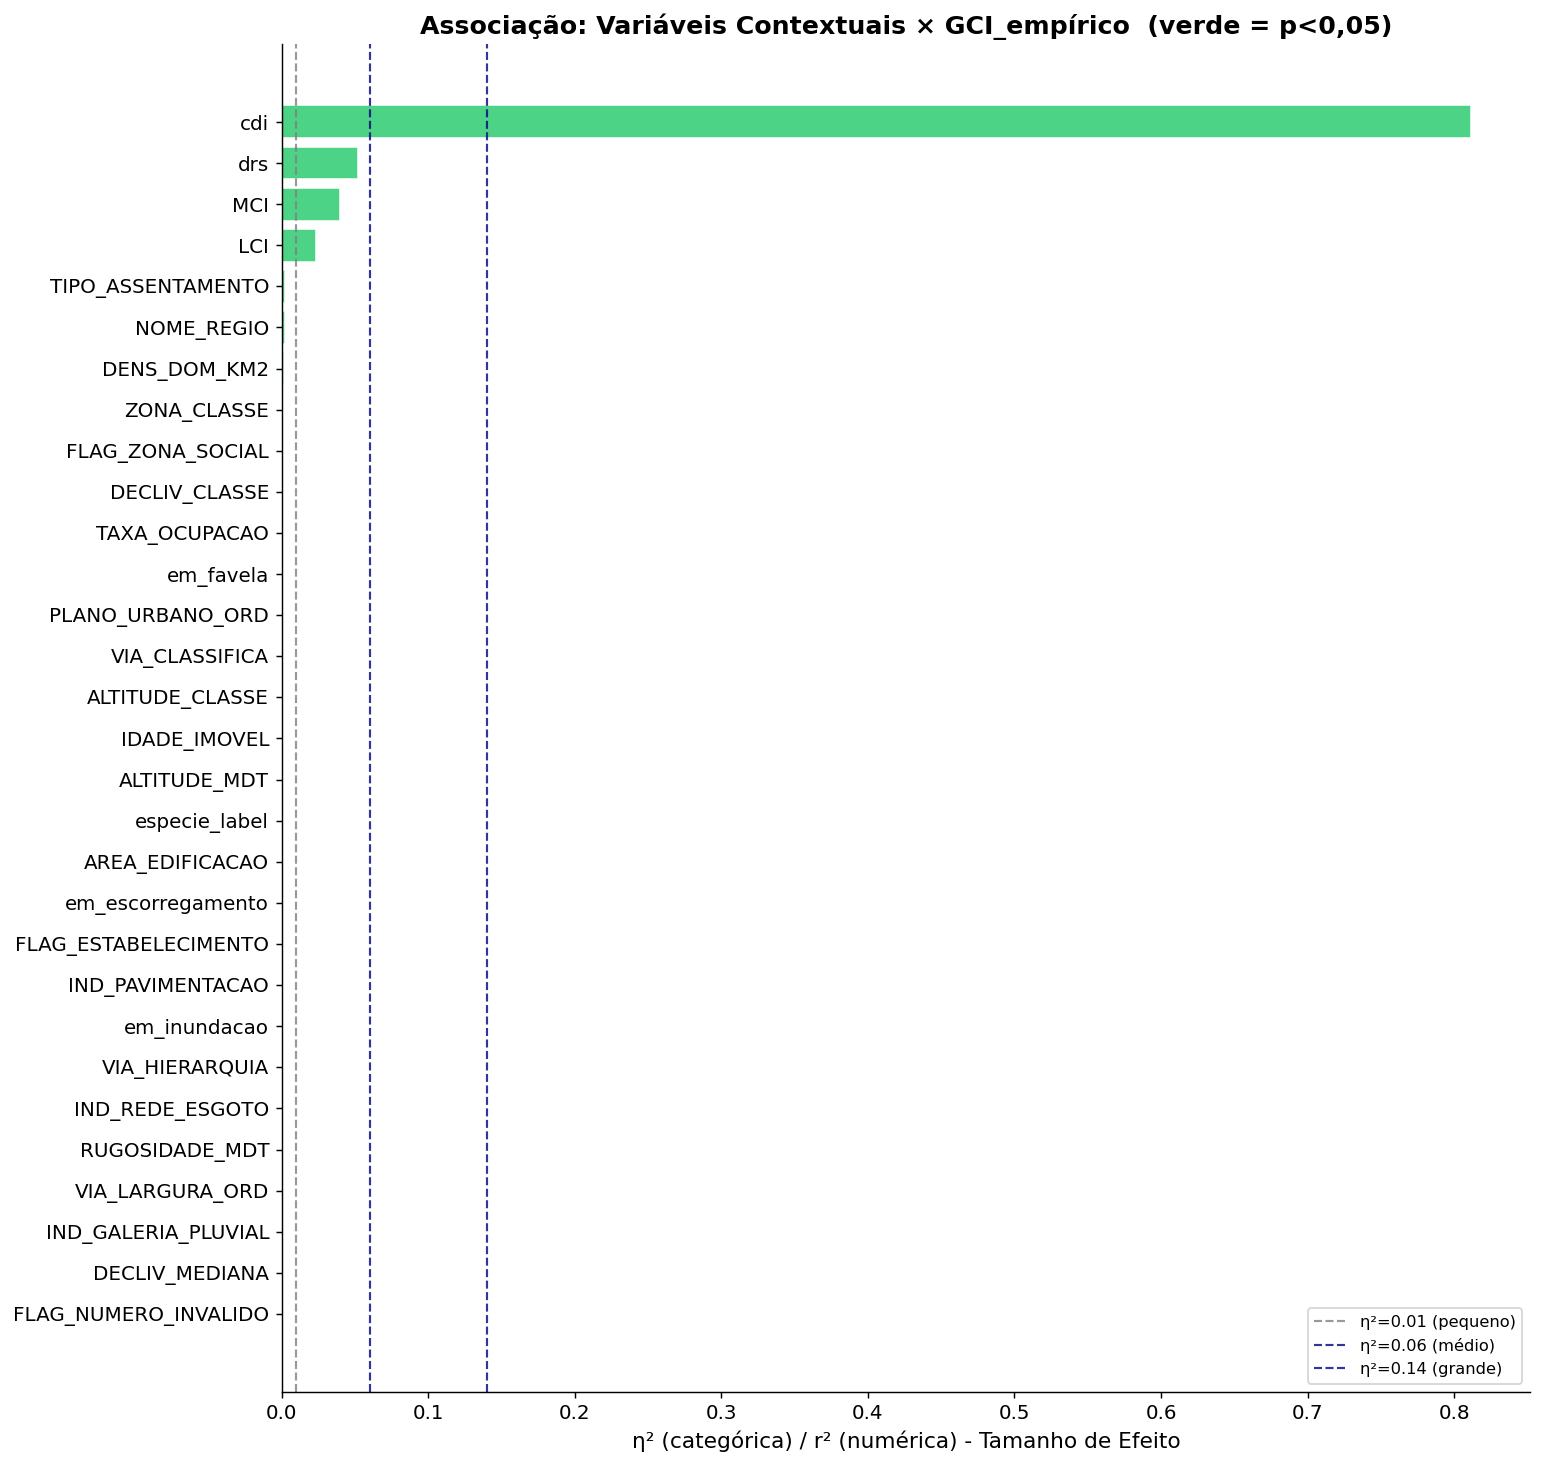

Salvo: nb08_eda_v3_associacoes_gci.csv


In [6]:
if m3 is None or 'GCI_empirico' not in m3.columns:
    print("Pulando: cnefe_master_metrics.parquet ou GCI_empirico não disponível.")
else:

    GCI_COL = 'GCI_empirico'
    assoc = []

    CAT_VARS = [c for c in [
        'VIA_CLASSIFICA', 'DECLIV_CLASSE', 'ZONA_CLASSE', 'TIPO_ASSENTAMENTO',
        'ALTITUDE_CLASSE', 'IND_GALERIA_PLUVIAL', 'IND_PAVIMENTACAO', 'IND_REDE_ESGOTO',
        'FLAG_ZONA_SOCIAL', 'FLAG_ESTABELECIMENTO', 'FLAG_NUMERO_INVALIDO',
        'em_favela', 'em_inundacao', 'em_escorregamento', 'especie_label', 'NOME_REGIO',
    ] if c in m3.columns]

    for col in CAT_VARS:
        sub = m3[[col, GCI_COL]].dropna()
        grupos = [sub.loc[sub[col] == g, GCI_COL].values for g in sub[col].unique()]
        grupos = [g for g in grupos if len(g) >= 30]
        if len(grupos) < 2:
            continue
        H, p = stats.kruskal(*grupos)
        n_tot = sum(len(g) for g in grupos)
        eta2 = max(0.0, (H - len(grupos) + 1) / (n_tot - len(grupos)))
        assoc.append({'Variável': col, 'Tipo': 'Cat', 'Teste': 'Kruskal-Wallis',
                      'Stat': H, 'p': p, 'Eta2_r2': eta2, 'N': n_tot})

    NUM_VARS = [c for c in [
        'VIA_HIERARQUIA', 'DECLIV_MEDIANA', 'ALTITUDE_MDT', 'RUGOSIDADE_MDT',
        'DENS_ATIV_ECON_KM2', 'DENS_DOM_KM2', 'PLANO_URBANO_ORD', 'VIA_LARGURA_ORD',
        'IDADE_IMOVEL', 'TAXA_OCUPACAO', 'AREA_EDIFICACAO', 'LCI', 'MCI', 'cdi', 'drs',
    ] if c in m3.columns]

    for col in NUM_VARS:
        sub = m3[[col, GCI_COL]].dropna()
        if len(sub) < 100:
            continue
        r, p = stats.spearmanr(sub[col], sub[GCI_COL])
        assoc.append({'Variável': col, 'Tipo': 'Num', 'Teste': 'Spearman',
                      'Stat': r, 'p': p, 'Eta2_r2': r**2, 'N': len(sub)})

    assoc_df = pd.DataFrame(assoc).sort_values('Eta2_r2', ascending=False)
    assoc_df['Sig'] = assoc_df['p'] < 0.05

    print(f"Associações significativas (p<0.05): {assoc_df['Sig'].sum()}/{len(assoc_df)}")
    print(f"Efeito mediano (Eta²/r²): {assoc_df['Eta2_r2'].median():.4f}")

    display(assoc_df[['Variável', 'Tipo', 'Teste', 'Stat', 'p', 'Eta2_r2', 'N', 'Sig']].style
        .apply(lambda row: ['background-color: #d5f5e3' if row['Sig']
                            else 'background-color: #fdedec' for _ in row], axis=1)
        .format({'Stat': '{:.3f}', 'p': '{:.2e}', 'Eta2_r2': '{:.4f}', 'N': '{:,.0f}'})
        .bar(subset=['Eta2_r2'], color='#85c1e9', vmin=0)
        .set_caption('Associações: variáveis contextuais × GCI_empírico (verde = p<0,05)'))

    fig, ax = plt.subplots(figsize=(12, max(6, len(assoc_df) * 0.38)))
    plot_df = assoc_df.sort_values('Eta2_r2', ascending=True)
    colors = ['#2ecc71' if s else '#e74c3c' for s in plot_df['Sig']]
    ax.barh(plot_df['Variável'], plot_df['Eta2_r2'], color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0.01, color='gray', ls='--', lw=1.2, alpha=0.8, label='η²=0.01 (pequeno)')
    ax.axvline(0.06, color='navy', ls='--', lw=1.2, alpha=0.8, label='η²=0.06 (médio)')
    ax.axvline(0.14, color='darkblue', ls='--', lw=1.2, alpha=0.8, label='η²=0.14 (grande)')
    ax.set_xlabel('η² (categórica) / r² (numérica) - Tamanho de Efeito')
    ax.set_title('Associação: Variáveis Contextuais × GCI_empírico  (verde = p<0,05)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb08_associacoes_gci.png', bbox_inches='tight', dpi=130)
    plt.show()

    assoc_df.to_csv(config.TAB_DIR / 'nb08_associacoes_gci.csv', index=False)
    print("Salvo: nb08_eda_v3_associacoes_gci.csv")

Triagem KW/Spearman: as variáveis com efeito mais expressivo (η² ou r² > 0,01) são as que envolvem diretamente a estrutura edilícia que gera CDI alto (PAV_EST, TIPOLOGIA_BROAD). As variáveis socioeconômicas (IVS, INFRA) têm associação estatisticamente significativa com N=1,1M mas efeito prático menor, o CDI domina sobre o contexto.

---
### 2.5 Cramér's V: Associação Categórica × Categórica

O V de Cramér complementa a triagem anterior (Kruskal-Wallis e Spearman): enquanto o KW mede associação entre variável categórica e o GCI contínuo, o V de Cramér mede associação entre **pares de variáveis categóricas**, revelando se as segmentações contextuais são redundantes entre si ou capturam dimensões independentes da estrutura urbana.

**Interpretação de |V|:** negligenciável < 0,10 < fraco < 0,20 < moderado < 0,35 < forte

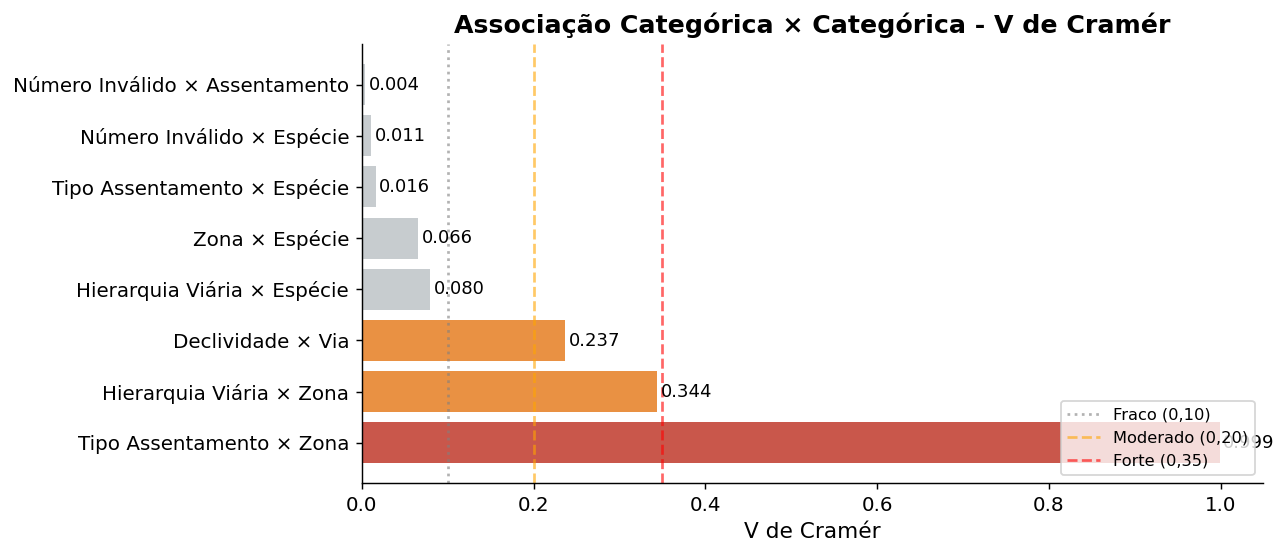

Par,V Cramér,Interpretação
Tipo Assentamento × Zona,0.999,forte
Hierarquia Viária × Zona,0.344,moderado
Declividade × Via,0.237,moderado
Hierarquia Viária × Espécie,0.080,negligenciável
Zona × Espécie,0.066,negligenciável
Tipo Assentamento × Espécie,0.016,negligenciável
Número Inválido × Espécie,0.011,negligenciável
Número Inválido × Assentamento,0.004,negligenciável


Pares com associação forte (V ≥ 0,35): 1


In [7]:
# V de Cramér: associação categórica × categórica entre variáveis v3
if m3 is None:
    print('cnefe_master_metrics.parquet não encontrado — execute: python run_pipeline.py --from etl')
else:
    from scipy.stats import chi2_contingency

    def cramers_v(x, y):
        ct = pd.crosstab(x.fillna('NA'), y.fillna('NA'))
        chi2, _, _, _ = chi2_contingency(ct, correction=False)
        n = ct.values.sum()
        k = min(ct.shape) - 1
        return float(np.sqrt(chi2 / (n * k))) if k > 0 and n > 0 else np.nan

    CAT_PAIRS = [
        ('VIA_CLASSIFICA',    'especie_label',   'Hierarquia Viária × Espécie'),
        ('VIA_CLASSIFICA',    'ZONA_TIPO',        'Hierarquia Viária × Zona'),
        ('DECLIV_CLASSE',     'VIA_CLASSIFICA',   'Declividade × Via'),
        ('TIPO_ASSENTAMENTO', 'especie_label',    'Tipo Assentamento × Espécie'),
        ('TIPO_ASSENTAMENTO', 'ZONA_TIPO',        'Tipo Assentamento × Zona'),
        ('ZONA_TIPO',         'especie_label',    'Zona × Espécie'),
        ('FLAG_NUMERO_INVALIDO', 'especie_label', 'Número Inválido × Espécie'),
        ('FLAG_NUMERO_INVALIDO', 'TIPO_ASSENTAMENTO', 'Número Inválido × Assentamento'),
    ]

    if 'especie_label' not in m3.columns:
        m3['especie_label'] = m3['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido')

    results_v = []
    for col_a, col_b, label in CAT_PAIRS:
        if col_a not in m3.columns or col_b not in m3.columns:
            continue
        sub = m3[[col_a, col_b]].dropna()
        if len(sub) < 100:
            continue
        v = cramers_v(sub[col_a], sub[col_b])
        results_v.append({'Par': label, 'V Cramér': round(v, 3),
                          'Interpretação': ('forte' if v >= 0.35 else 'moderado' if v >= 0.20
                                            else 'fraco' if v >= 0.10 else 'negligenciável')})

    df_cv = pd.DataFrame(results_v).sort_values('V Cramér', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_cv) * 0.55)))
    colors_cv = ['#c0392b' if v >= 0.35 else '#e67e22' if v >= 0.20 else
                 '#f1c40f' if v >= 0.10 else '#bdc3c7' for v in df_cv['V Cramér']]
    bars = ax.barh(df_cv['Par'], df_cv['V Cramér'], color=colors_cv, alpha=0.85)
    for bar, v in zip(bars, df_cv['V Cramér']):
        ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    ax.axvline(0.10, color='gray',   linestyle=':', alpha=0.6, label='Fraco (0,10)')
    ax.axvline(0.20, color='orange', linestyle='--', alpha=0.6, label='Moderado (0,20)')
    ax.axvline(0.35, color='red',    linestyle='--', alpha=0.6, label='Forte (0,35)')
    ax.set_xlabel('V de Cramér')
    ax.set_title('Associação Categórica × Categórica - V de Cramér', fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb08_cramer_v_categoricas.png', dpi=200, bbox_inches='tight')
    plt.show()

    display(df_cv.style
        .background_gradient(subset=['V Cramér'], cmap='YlOrRd', vmin=0, vmax=0.5)
        .format({'V Cramér': '{:.3f}'})
        .set_caption('V de Cramér — associação entre pares de variáveis categóricas v3')
        .hide(axis='index'))

    df_cv.to_csv(config.TAB_DIR / 'nb08_cramer_v_categoricas.csv', index=False)
    forte = (df_cv['V Cramér'] >= 0.35).sum()
    print(f'Pares com associação forte (V ≥ 0,35): {forte}')


O V de Cramér entre pares de variáveis categóricas contextualiza a triagem anterior: pares com V > 0,3 indicam redundância potencial nos modelos dos NB09, NB12. VIA_CLASSIFICA e ZONA_TIPO tendem a ser correlacionados geograficamente, a escolha de qual incluir nos modelos deve considerar a interpretação substantiva.

---
### 2.6 Síntese da Triagem de Covariáveis

| Dimensão | Evidência | Implicação |
|---|---|---|
| **GCI_empírico vs GCI_original por regional** | GCI_empírico sistematicamente inferior; delta máximo no Centro-Sul e Hipercentro | H1 confirmada por regional |
| **Variáveis contextuais** | 79/114 colunas com cobertura ≥ 80%; todas as segmentações H1–H8 com N_min ≥ 30 para KW | Viabilidade confirmada para NB09–NB12 |
| **Triagem KW/Spearman** | `cdi`, `especie_label` e `NOME_REGIO` com efeitos mais expressivos; `em_favela` com η²≈0,0004 (negligenciável) | Priorização de variáveis para modelagem |
| **FLAG_NUMERO_INVALIDO** | 6,6% dos registros com numeração inválida no BHMap, fator de contaminação silencioso | Covariável de controle para NB12 |

---
## 3. EDA das Camadas de Contexto BHMap

Sete camadas contextuais foram incorporadas ao projeto (processadas por `scripts/process_context_layers.py`):

| Camada | Arquivo | Registros | Tipo |
|---|---|---|---|
| Edificações | `edificacao.parquet` | ~250k polígonos | Vetor polígono |
| Áreas de risco | `area_risco.parquet` | 2 tipos dissolvidos | Vetor polígono |
| IVS | `ivs.parquet` | 5.166 setores | Vetor polígono |
| Lotes CTM + tipologia | `lote_ctm.parquet` | ~370k lotes | Vetor polígono |
| Bairros populares | `bairro_popular.parquet` | 493 bairros | Vetor polígono |
| Cadastro, unidades | `cadastro_units.parquet` | ~897k unidades | Tabela |
| Cadastro, lotes | `cadastro_lotes.parquet` | ~306k lotes | Vetor polígono |

**Objetivo:** caracterizar cada camada, verificar consistência geométrica e geográfica, identificar distribuições e outliers, e alinhar cada variável com as hipóteses de pesquisa.

> **Bloco movido do NB03 (EDA das bases).** Esta caracterização das camadas de contexto BHMap foi realocada do Notebook 03 para consolidar com o screening de covariáveis deste notebook. As saídas exibidas refletem a última execução no NB03; a célula de setup abaixo relê as fontes (`cnefe_bh.parquet`, `cnefe_coordinate_metrics.parquet`, shapefile de regionais) para que o bloco rode de forma autônoma aqui.

In [8]:
# Setup do bloco de EDA das camadas de contexto (movido do NB03).
# Reconstroi as variaveis-base que o bloco usa, lendo direto das fontes.
cnefe = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_bh.parquet')
if cnefe.crs and cnefe.crs.to_epsg() != 31983:
    cnefe = cnefe.to_crs(config.TARGET_CRS)
cnefe_m = cnefe.to_crs('EPSG:31983')
regionais = gpd.read_file(config.REGIONAIS_SHP).rename(columns={'NOME': 'NOME_REGIO'})
regionais_m = regionais.to_crs('EPSG:31983')
coord_m = pd.read_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
PALETA_REGIONAL = {
    'BARREIRO': '#e41a1c', 'CENTRO-SUL': '#377eb8', 'HIPERCENTRO': '#ff7f00',
    'LESTE': '#4daf4a', 'NORDESTE': '#984ea3', 'NOROESTE': '#a65628',
    'NORTE': '#f781bf', 'OESTE': '#999999', 'PAMPULHA': '#66c2a5',
    'VENDA NOVA': '#fc8d62',
}
print(f'Setup contexto: cnefe={len(cnefe):,} | regionais={len(regionais)} | coord_m={len(coord_m):,}')

Setup contexto: cnefe=1,180,102 | regionais=10 | coord_m=1,180,102


In [9]:
# Carregar todas as camadas de contexto processadas
import warnings
warnings.filterwarnings('ignore')

edificacao   = gpd.read_parquet(config.EDIFICACAO_PARQUET)
area_risco   = gpd.read_parquet(config.AREA_RISCO_PARQUET)
ivs          = gpd.read_parquet(config.IVS_PARQUET)
lote_ctm     = gpd.read_parquet(config.LOTE_CTM_PARQUET)
bairro_pop   = gpd.read_parquet(config.BAIRRO_POPULAR_PARQUET)
cad_units    = pd.read_parquet(config.CADASTRO_UNITS_PARQUET)
cad_lotes    = gpd.read_parquet(config.CADASTRO_LOTES_PARQUET)

# Reprojetar tudo para CRS métrico
for name, gdf in [('edificacao', edificacao), ('area_risco', area_risco),
                   ('ivs', ivs), ('lote_ctm', lote_ctm),
                   ('bairro_pop', bairro_pop), ('cad_lotes', cad_lotes)]:
    if gdf.crs and gdf.crs.to_epsg() != 31983:
        exec(f"{name} = {name}.to_crs('EPSG:31983')", globals())

# Sumário de carregamento
camadas = {
    'edificacao':   edificacao,
    'area_risco':   area_risco,
    'ivs':          ivs,
    'lote_ctm':     lote_ctm,
    'bairro_pop':   bairro_pop,
    'cad_lotes':    cad_lotes,
}
print(f"{'Camada':<20} {'N':>8}  {'CRS':<20}  {'Tipo geom':>15}")
print("-" * 70)
for name, gdf in camadas.items():
    crs_str = str(gdf.crs.to_epsg()) if gdf.crs else "sem CRS"
    geom_types = gdf.geometry.geom_type.value_counts().index[0]
    print(f"{name:<20} {len(gdf):>8,}  EPSG:{crs_str:<16}  {geom_types:>15}")
print(f"\ncad_units (tabela): {len(cad_units):,} unidades")

Camada                      N  CRS                         Tipo geom
----------------------------------------------------------------------
edificacao            739,354  EPSG:31983                     Polygon
area_risco                  2  EPSG:31983                MultiPolygon
ivs                     3,936  EPSG:31983                     Polygon
lote_ctm              365,444  EPSG:31983                     Polygon
bairro_pop                493  EPSG:31983                     Polygon


cad_lotes             306,352  EPSG:31983                MultiPolygon

cad_units (tabela): 896,964 unidades


### 3.1 Camada EDIFICACAO: Geometria, Alturas e Flags de Qualidade

**Hipótese H1 (CDI-Verticalização):** Edifícios com PAV_EST alto concentram-se no Hipercentro e Centro-Sul. O CDI alto nessas regionais é estruturalmente explicado pela densidade de edificações verticais, o IBGE coleta uma coordenada GPS por edifício e atribui a todos os apartamentos.

**Sanidade geométrica esperada:** polígonos sem buracos, área mínima ~10 m², sem auto-interseções.

=== EDIFICACAO — Sanidade geométrica ===
  Total edificações:       739,354
  Geometrias válidas:      739,354  (100.00%)
  Geometrias inválidas:    0
  Área calculada (m²) — mediana:  88.2
  Área calculada (m²) — P99:      709.0
  ALTURA_CAL < 0 (remanescentes): 0
  ALTURA_EST < 0 (remanescentes): 0
  FLAG_EM_CONSTRUCAO=1:    11,015  (1.49%)
  FLAG_ALTURA_IMPRECISA=1: 8,353  (1.13%)


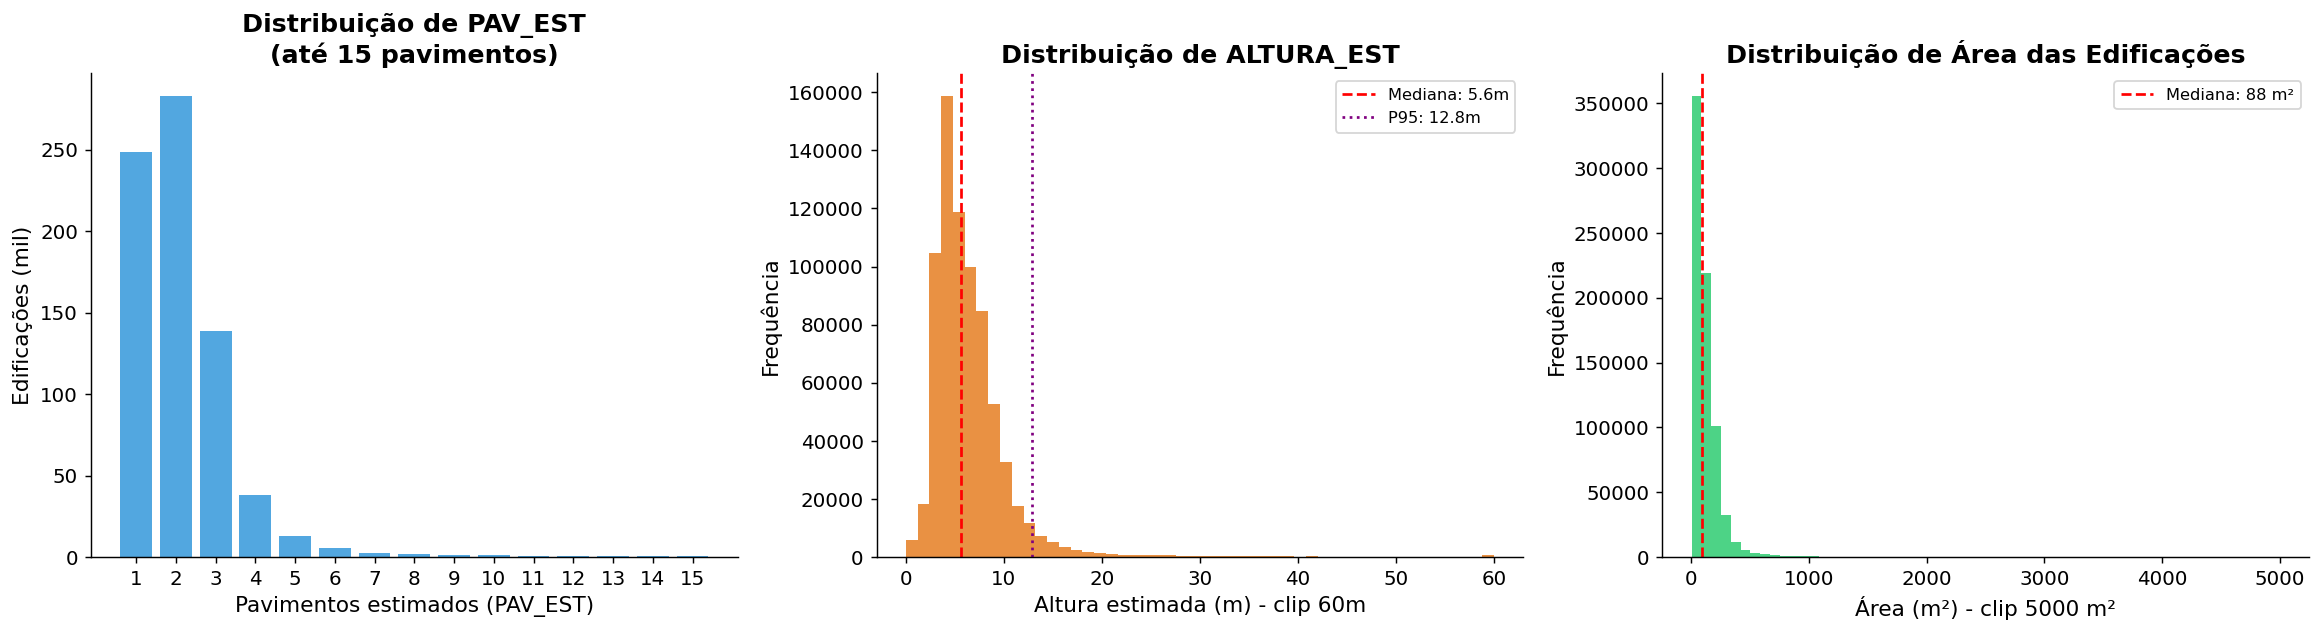

,count,mean,std,min,25%,50%,75%,max
ALTURA_CAL,739354.00,6.62,5.00,0.00,4.03,5.58,7.82,129.32
ALTURA_EST,739354.00,6.62,5.00,0.00,4.03,5.58,7.82,129.32
PAV_EST,739354.00,2.20,1.69,1.00,1.00,2.00,3.00,43.00
AREA_CALC,739354.00,125.54,318.00,0.72,42.32,88.19,157.06,112293.36


In [10]:
# 3.1a — Sanidade geométrica: área, validade, flags
edif = edificacao.copy()
edif['AREA_CALC'] = edif.geometry.area
edif['VALIDA']    = edif.geometry.is_valid
edif['VAZIA']     = edif.geometry.is_empty

print("=== EDIFICACAO — Sanidade geométrica ===")
print(f"  Total edificações:       {len(edif):,}")
print(f"  Geometrias válidas:      {edif['VALIDA'].sum():,}  ({edif['VALIDA'].mean()*100:.2f}%)")
print(f"  Geometrias inválidas:    {(~edif['VALIDA']).sum():,}")
print(f"  Área calculada (m²) — mediana:  {edif['AREA_CALC'].median():.1f}")
print(f"  Área calculada (m²) — P99:      {edif['AREA_CALC'].quantile(.99):.1f}")
print(f"  ALTURA_CAL < 0 (remanescentes): {(edif['ALTURA_CAL'] < 0).sum():,}")
print(f"  ALTURA_EST < 0 (remanescentes): {(edif['ALTURA_EST'] < 0).sum():,}")
if 'FLAG_EM_CONSTRUCAO' in edif.columns:
    print(f"  FLAG_EM_CONSTRUCAO=1:    {edif['FLAG_EM_CONSTRUCAO'].sum():,}  ({edif['FLAG_EM_CONSTRUCAO'].mean()*100:.2f}%)")
    print(f"  FLAG_ALTURA_IMPRECISA=1: {edif['FLAG_ALTURA_IMPRECISA'].sum():,}  ({edif['FLAG_ALTURA_IMPRECISA'].mean()*100:.2f}%)")

# Distribuição de PAV_EST e ALTURA_EST
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
pav_vc = edif['PAV_EST'].value_counts().sort_index().head(15)
ax.bar(pav_vc.index.astype(str), pav_vc.values / 1000, color='#3498db', alpha=0.85)
ax.set_xlabel('Pavimentos estimados (PAV_EST)')
ax.set_ylabel('Edificações (mil)')
ax.set_title('Distribuição de PAV_EST\n(até 15 pavimentos)', fontweight='bold')
ax.tick_params(axis='x', rotation=0)

ax = axes[1]
h = edif['ALTURA_EST'].clip(upper=60).dropna()
ax.hist(h, bins=50, color='#e67e22', alpha=0.85, edgecolor='none')
ax.axvline(h.median(), color='red', linestyle='--', label=f'Mediana: {h.median():.1f}m')
ax.axvline(h.quantile(.95), color='purple', linestyle=':', label=f'P95: {h.quantile(.95):.1f}m')
ax.set_xlabel('Altura estimada (m) - clip 60m')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de ALTURA_EST', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[2]
area_clip = edif['AREA_CALC'].clip(upper=5000).dropna()
ax.hist(area_clip, bins=60, color='#2ecc71', alpha=0.85, edgecolor='none')
ax.axvline(area_clip.median(), color='red', linestyle='--', label=f'Mediana: {area_clip.median():.0f} m²')
ax.set_xlabel('Área (m²) - clip 5000 m²')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Área das Edificações', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_edificacao_dist.png', bbox_inches='tight')
plt.show()

# Stats descritivas
cols_stat = [c for c in ['ALTURA_CAL','ALTURA_EST','PAV_EST','AREA_CALC'] if c in edif.columns]
display(edif[cols_stat].describe().T.style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.2f}')
    .set_caption('EDIFICACAO — estatísticas descritivas'))

Métricas de sanidade (área inválida, flags de construção) confirmam a qualidade dos polígonos BHMap usados para calcular PAV_EST (andares) e área construída.

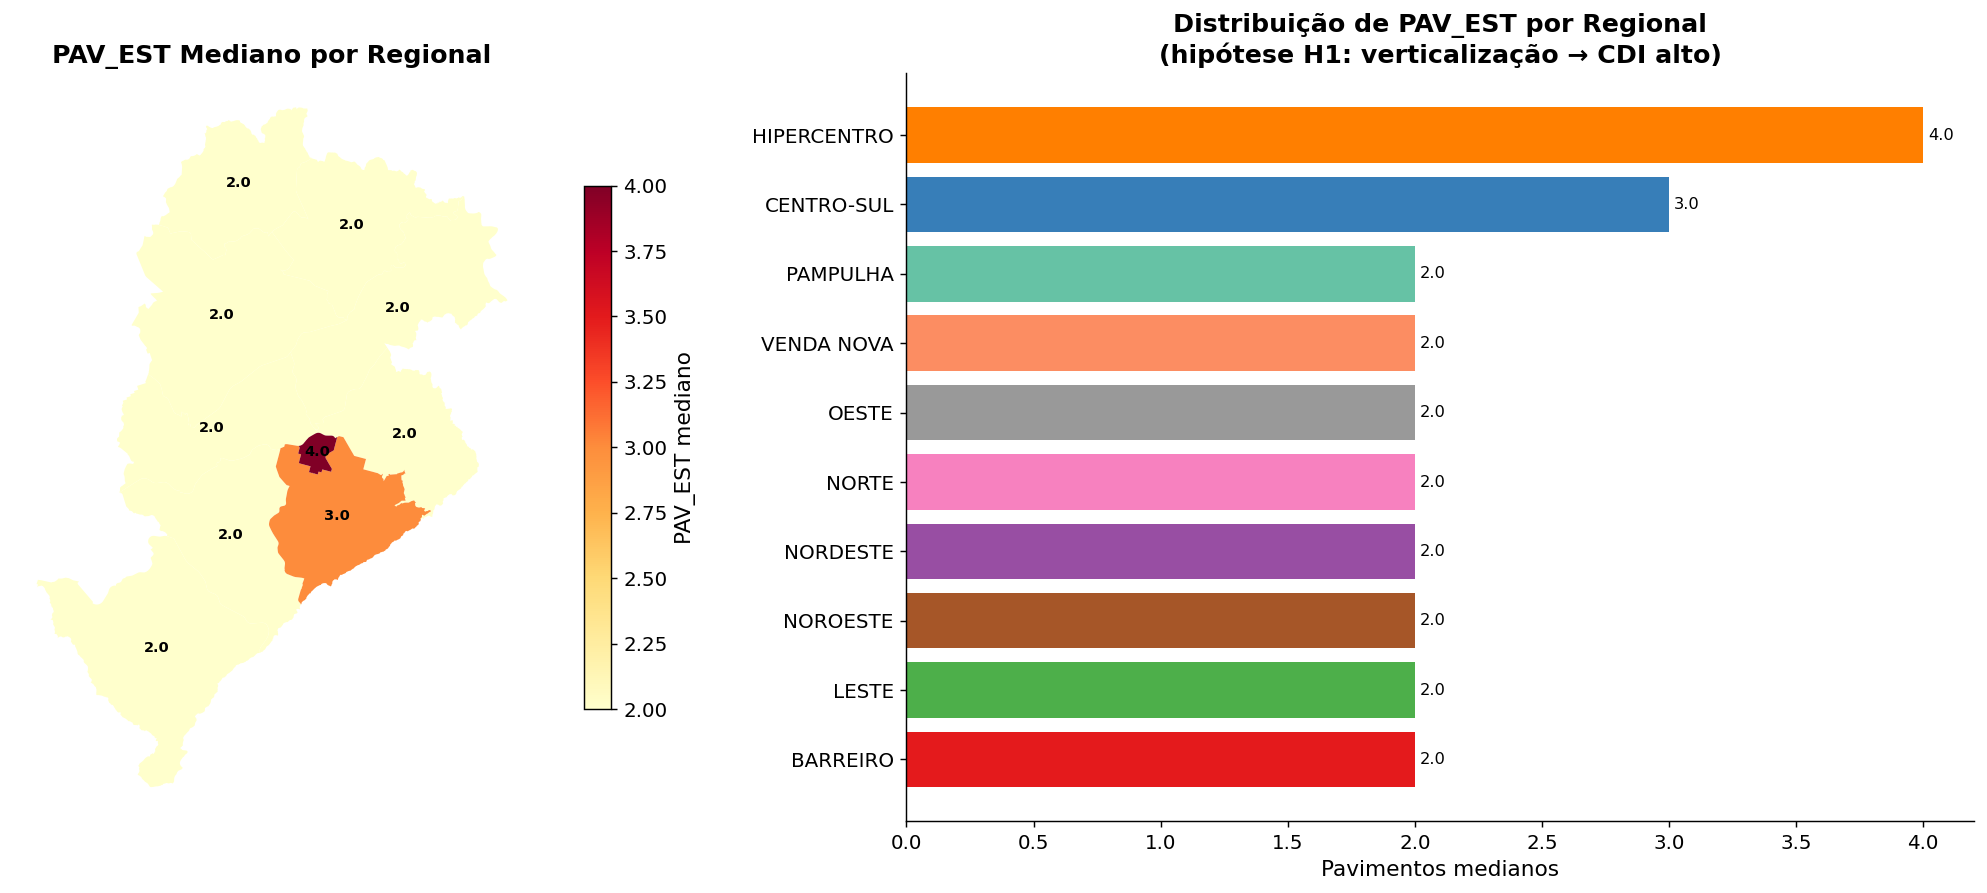

,PAV_mediana,PAV_media,PAV_max
NOME_REGIO,,,
HIPERCENTRO,4.00,6.80,42.00
CENTRO-SUL,3.00,3.53,43.00
BARREIRO,2.00,1.91,19.00
LESTE,2.00,2.12,37.00
NORDESTE,2.00,2.18,36.00
NOROESTE,2.00,2.07,23.00
NORTE,2.00,1.96,21.00
OESTE,2.00,2.41,32.00
PAMPULHA,2.00,2.09,27.00


In [11]:
# 3.1b — Mapa coroplético: PAV_EST mediano por regional
regionais_m = regionais.to_crs('EPSG:31983')

# Spatial join edificações × regionais (centroides para velocidade)
edif_centroid = edif.copy()
edif_centroid['geometry'] = edif.geometry.centroid
edif_reg = gpd.sjoin(edif_centroid[['PAV_EST','geometry']], regionais_m[['NOME_REGIO','geometry']],
                      how='left', predicate='within')
pav_by_reg = edif_reg.groupby('NOME_REGIO')['PAV_EST'].agg(['median','mean','max']).round(2)
pav_by_reg.columns = ['PAV_mediana','PAV_media','PAV_max']

regionais_plot = regionais_m.merge(pav_by_reg, on='NOME_REGIO', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
regionais_plot.plot(column='PAV_mediana', cmap='YlOrRd', legend=True, ax=ax,
                    legend_kwds={'label': 'PAV_EST mediano', 'shrink': 0.7})
for _, row in regionais_plot.iterrows():
    c = row.geometry.centroid
    val = row['PAV_mediana']
    if not pd.isna(val):
        ax.text(c.x, c.y, f'{val:.1f}', ha='center', va='center', fontsize=8, fontweight='bold')
ax.set_title('PAV_EST Mediano por Regional', fontweight='bold')
ax.axis('off')

ax = axes[1]
pav_sorted = pav_by_reg.sort_values('PAV_mediana', ascending=True)
colors = [PALETA_REGIONAL.get(r, '#aaa') for r in pav_sorted.index]
ax.barh(pav_sorted.index, pav_sorted['PAV_mediana'], color=colors)
ax.set_xlabel('Pavimentos medianos')
ax.set_title('Distribuição de PAV_EST por Regional\n(hipótese H1: verticalização → CDI alto)', fontweight='bold')
for i, (reg, row) in enumerate(pav_sorted.iterrows()):
    ax.text(row['PAV_mediana'] + 0.02, i, f'{row["PAV_mediana"]:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_edificacao_pav_regional.png', bbox_inches='tight')
plt.show()

display(pav_by_reg.sort_values('PAV_mediana', ascending=False).style
    .background_gradient(cmap='YlOrRd', subset=['PAV_mediana'])
    .background_gradient(cmap='YlOrRd', subset=['PAV_media'])
    .format('{:.2f}')
    .set_caption('Estatísticas de PAV_EST por Regional'))

PAV_EST mediano por regional quantifica a verticalidade de cada área. Regionais com PAV_EST alto (Hipercentro, Centro-Sul) correspondem a áreas onde o CDI deve ser alto e o GCI_empírico mais baixo.

### 3.2 Camada AREA_RISCO: Cobertura Territorial e Sobreposição com CNEFE

**Hipótese H2 (Qualidade em assentamentos informais):** Áreas de risco concentram domicílios precários onde o IBGE pode ter coletado coordenadas GPS estimadas (NV≥2), resultando em LCI baixo. A combinação `AREA_RISCO + IVS_SCORE alto` define um estrato de vulnerabilidade composta, espera-se GCI_empirico mais baixo nesse estrato.

**Sanidade:** verificar se os polígonos dissolvidos são válidos, cobrem frações plausíveis do território e se há sobreposição entre tipos de risco.

=== AREA_RISCO — Sanidade geométrica ===
  ESCORREGAMENTO: válido=True, área=29.61 km²  (8.9% de BH)
  INUNDACAO: válido=True, área=9.40 km²  (2.8% de BH)

  Sobreposição INUNDACAO ∩ ESCORREGAMENTO: 0.117 km²



  CNEFE em área de risco (qualquer tipo): 93,275 (7.9%)
    Sem risco: 1,086,827 (92.1%)
    ESCORREGAMENTO: 74,036 (6.3%)
    INUNDACAO: 19,239 (1.6%)


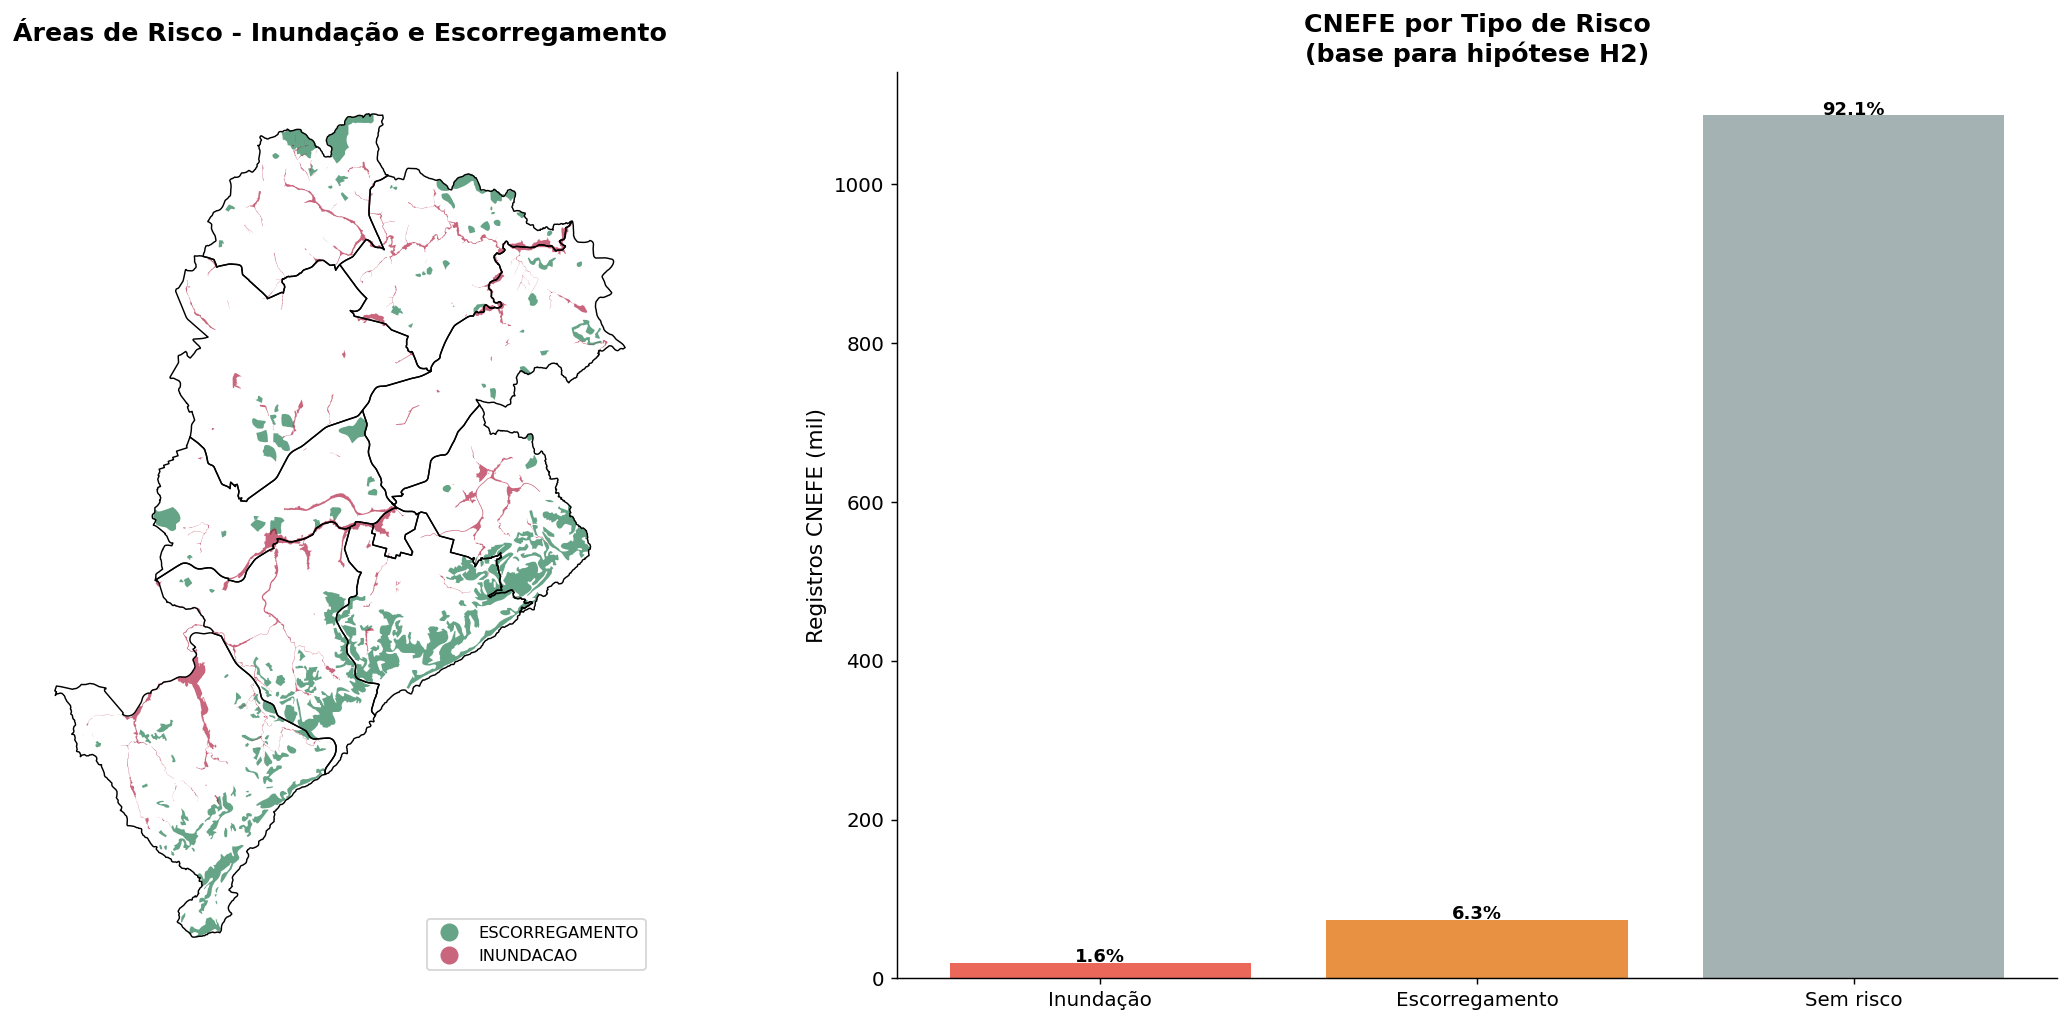

In [12]:
# 3.2 — EDA AREA_RISCO
risco = area_risco.copy()
bh_total_m2 = regionais_m.geometry.union_all().area

print("=== AREA_RISCO — Sanidade geométrica ===")
for _, row in risco.iterrows():
    tipo   = row['TIPO_RISCO']
    valida = row.geometry.is_valid
    area   = row.geometry.area / 1e6  # km²
    pct_bh = row.geometry.area / bh_total_m2 * 100
    print(f"  {tipo}: válido={valida}, área={area:.2f} km²  ({pct_bh:.1f}% de BH)")

# Sobreposição entre tipos
inund_geom  = risco[risco['TIPO_RISCO'] == 'INUNDACAO'].geometry.iloc[0]
escorr_geom = risco[risco['TIPO_RISCO'] == 'ESCORREGAMENTO'].geometry.iloc[0]
inter_area  = inund_geom.intersection(escorr_geom).area / 1e6
print(f"\n  Sobreposição INUNDACAO ∩ ESCORREGAMENTO: {inter_area:.3f} km²")

# Mapa com CNEFE em risco
cnefe_m = cnefe.to_crs('EPSG:31983')
cnefe_risco = gpd.sjoin(cnefe_m[['geometry']], risco[['TIPO_RISCO','geometry']],
                         how='left', predicate='within')
cnefe_risco = cnefe_risco[~cnefe_risco.index.duplicated(keep='first')]
cnefe_risco['em_risco'] = cnefe_risco['TIPO_RISCO'].notna()

pct_risco_total = cnefe_risco['em_risco'].mean() * 100
pct_por_tipo = cnefe_risco['TIPO_RISCO'].value_counts(dropna=False)

print(f"\n  CNEFE em área de risco (qualquer tipo): {cnefe_risco['em_risco'].sum():,} ({pct_risco_total:.1f}%)")
for k, v in pct_por_tipo.items():
    label = str(k) if not pd.isna(k) else 'Sem risco'
    print(f"    {label}: {v:,} ({v/len(cnefe)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
risco.plot(column='TIPO_RISCO', ax=ax, alpha=0.6,
           legend=True, cmap='RdYlGn_r',
           legend_kwds={'loc': 'lower right', 'fontsize': 9})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('Áreas de Risco - Inundação e Escorregamento', fontweight='bold')
ax.axis('off')

ax = axes[1]
labels_risco = ['Inundação', 'Escorregamento', 'Sem risco']
vals_risco = [
    (cnefe_risco['TIPO_RISCO'] == 'INUNDACAO').sum(),
    (cnefe_risco['TIPO_RISCO'] == 'ESCORREGAMENTO').sum(),
    (~cnefe_risco['em_risco']).sum(),
]
colors_risco = ['#e74c3c', '#e67e22', '#95a5a6']
bars = ax.bar(labels_risco, [v/1000 for v in vals_risco], color=colors_risco, alpha=0.85)
ax.set_ylabel('Registros CNEFE (mil)')
ax.set_title('CNEFE por Tipo de Risco\n(base para hipótese H2)', fontweight='bold')
for bar, val in zip(bars, vals_risco):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val/len(cnefe)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_area_risco.png', bbox_inches='tight')
plt.show()

### 3.3 Camada IVS: Índice de Vulnerabilidade em Saúde por Setor

**Hipótese H2 + H3:** O IVS captura vulnerabilidade socioeconômica ao nível de setor censitário. Setores com IVS "Muito Elevado" tendem a ter menor infraestrutura de serviços urbanos e pior qualidade de geocodificação. A correlação IVS × GCI_empirico testa se vulnerabilidade social se traduz em pior posicionamento GPS.

**Nota metodológica:** IVS é de 2012 (BH), pode não refletir transformações urbanas pós-2012, especialmente em áreas de expansão recente. Setores FLAG_NAO_AVALIADO devem ser tratados como missing, não como baixa vulnerabilidade.

=== IVS — Distribuição ===
  Total setores: 3,936
  Não avaliados (FLAG_NAO_AVALIADO=1): 106 (2.7%)
  Setores avaliados: 3,830

  Distribuição IVS_2012:
    Médio: 1460 (37.1%)
    Baixo: 1330 (33.8%)
    Elevado: 737 (18.7%)
    Muito Elevado: 303 (7.7%)
    Não Avaliado: 106 (2.7%)


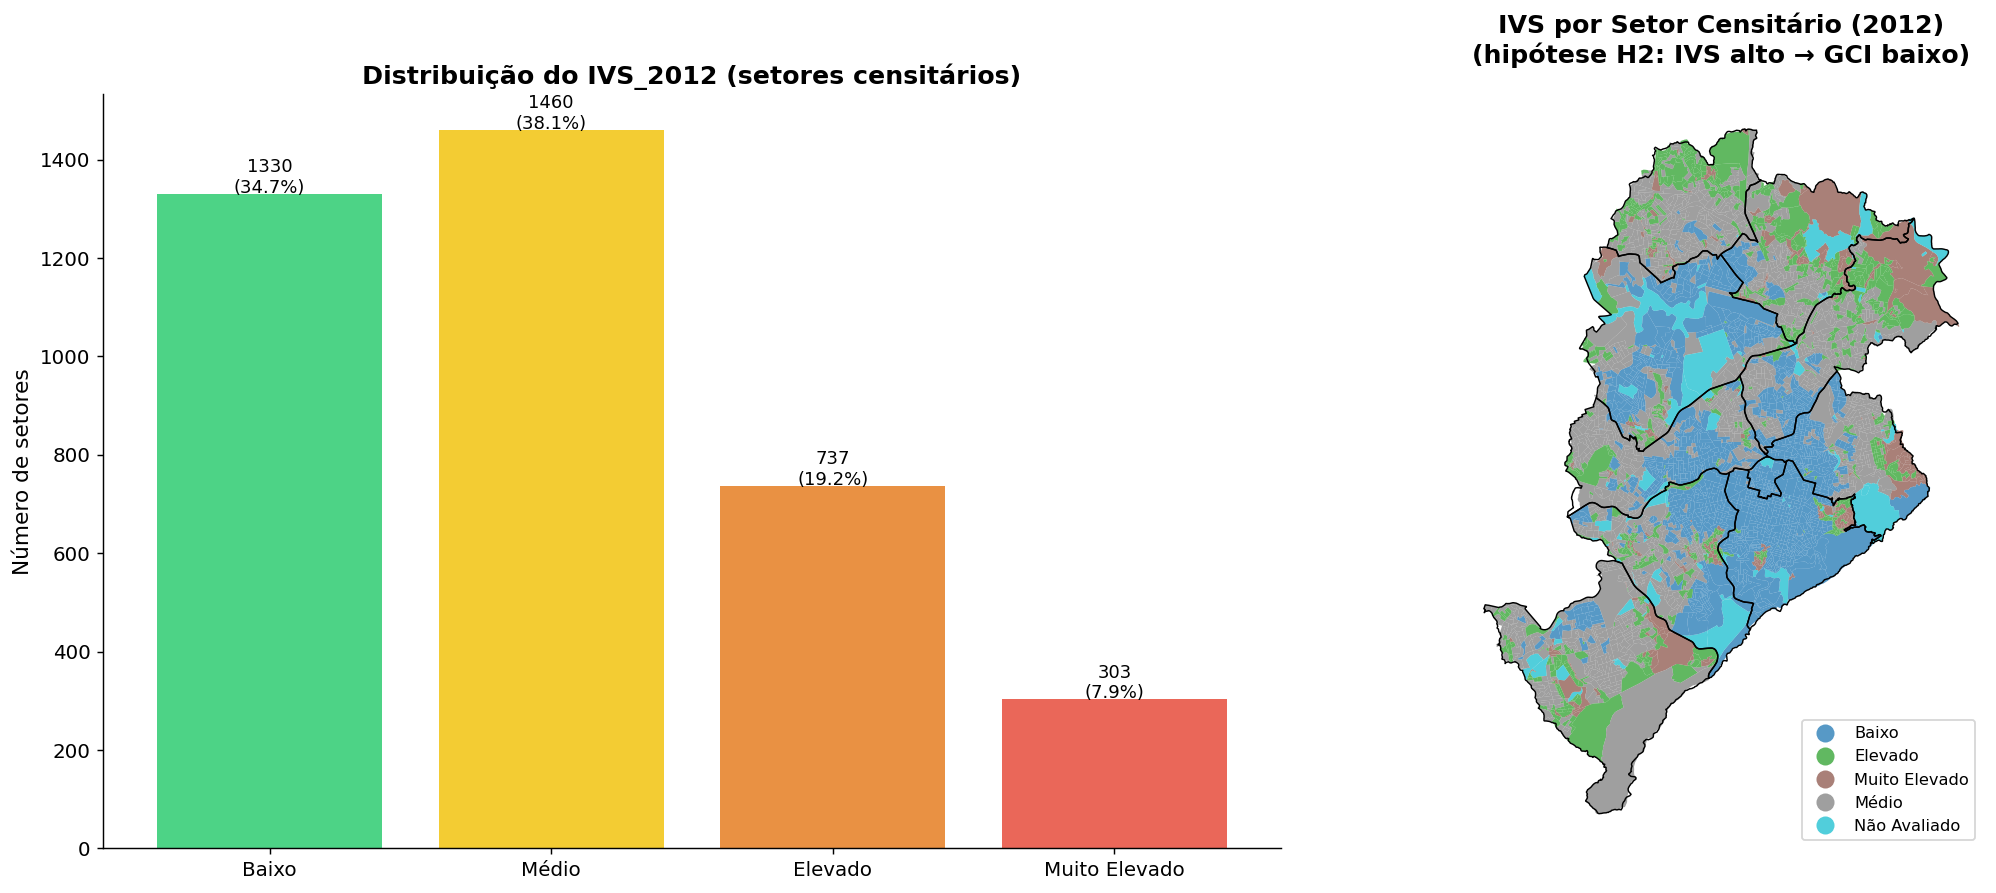


Cobertura IVS no CNEFE: 99.6% dos pontos
IVS_2012
Médio            38.1
Baixo            37.6
Elevado          16.1
Muito Elevado     7.0
Não Avaliado      0.8
NaN               0.4


In [13]:
# 3.3 — EDA IVS
ivs_df = ivs.copy()
print("=== IVS — Distribuição ===")
print(f"  Total setores: {len(ivs_df):,}")
if 'FLAG_NAO_AVALIADO' in ivs_df.columns:
    n_nao_av = int(ivs_df['FLAG_NAO_AVALIADO'].sum())
    print(f"  Não avaliados (FLAG_NAO_AVALIADO=1): {n_nao_av} ({n_nao_av/len(ivs_df)*100:.1f}%)")

ivs_avaliado = ivs_df[ivs_df['IVS_SCORE'].notna()]
print(f"  Setores avaliados: {len(ivs_avaliado):,}")

vc_ivs = ivs_df['IVS_2012'].value_counts(dropna=False)
print("\n  Distribuição IVS_2012:")
for k, v in vc_ivs.items():
    k_str = str(k) if not pd.isna(k) else 'Não Avaliado'
    print(f"    {k_str}: {v} ({v/len(ivs_df)*100:.1f}%)")

# Distribuição + mapa
order_ivs = ['Baixo', 'Médio', 'Elevado', 'Muito Elevado']
colors_ivs = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
ivs_cat_order = {k: i for i, k in enumerate(order_ivs)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
vc_plot = ivs_df['IVS_2012'].value_counts()
vc_order = [k for k in order_ivs if k in vc_plot.index]
vals = [vc_plot.get(k, 0) for k in vc_order]
bars = ax.bar(vc_order, vals, color=colors_ivs[:len(vc_order)], alpha=0.85)
ax.set_title('Distribuição do IVS_2012 (setores censitários)', fontweight='bold')
ax.set_ylabel('Número de setores')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{val}\n({val/len(ivs_avaliado)*100:.1f}%)', ha='center', fontsize=10)

ax = axes[1]
ivs_df['IVS_SCORE_fill'] = ivs_df['IVS_SCORE'].fillna(0)
ivs_df.plot(column='IVS_2012', ax=ax, alpha=0.75,
            legend=True, categorical=True,
            missing_kwds={'color': 'lightgray', 'label': 'Não Avaliado'},
            legend_kwds={'loc': 'lower right', 'fontsize': 9})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('IVS por Setor Censitário (2012)\n(hipótese H2: IVS alto → GCI baixo)', fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_ivs_dist_mapa.png', bbox_inches='tight')
plt.show()

# Distribuição de IVS por regional
cnefe_ivs = gpd.sjoin(cnefe_m[['geometry']], ivs_df[['IVS_2012','IVS_SCORE','geometry']],
                       how='left', predicate='within')
cnefe_ivs = cnefe_ivs[~cnefe_ivs.index.duplicated(keep='first')]
pct_ivs_cnefe = cnefe_ivs['IVS_2012'].value_counts(normalize=True, dropna=False).mul(100).round(1)
print(f"\nCobertura IVS no CNEFE: {cnefe_ivs['IVS_2012'].notna().mean()*100:.1f}% dos pontos")
print(pct_ivs_cnefe.to_string())

### 3.4 Camada LOTE_CTM + Tipologia: Uso do Solo e Morfologia

**Hipóteses H4 e H5:** A tipologia de uso/ocupação do lote (residencial, comercial, misto, industrial) é o preditor direto do tipo de edificação, e portanto do padrão CDI. A morfologia (isolada, geminada, em série, em conjunto) correlaciona-se com a verticalização e com a precisão GPS possível no ambiente construído.

**Achado crítico de cobertura:** ~60% dos lotes sem tipologia antes do preenchimento (agora categorizados como "SEM CLASSIFICACAO"). Isso reflete a incompletude do shapefile TIPOLOGIA_USO_OCUPACAO_LOTE_2022, não ausência de edificação. Lotes industriais e de uso especial tendem a ter menor cobertura tipológica.

=== LOTE_CTM — Sanidade geométrica ===
  Total lotes: 365,444
  Geometrias válidas: 365,444 (100.00%)
  Área mediana (m²): 360.3
  Área P99 (m²): 4499
  Lotes área < 1 m² (suspeitos): 0

  Top 10 TIPOLOGIA_BROAD:
    RESIDENCIAL                   : 149,403  (40.9%)
    SEM CLASSIFICACAO             : 124,293  (34.0%)
    SEM INFORMACAO                :  41,412  (11.3%)
    MISTO                         :  20,146  (5.5%)
    LOTE VAGO                     :  17,034  (4.7%)
    NAO RESIDENCIAL               :  12,907  (3.5%)
    PARQUE                        :     249  (0.1%)


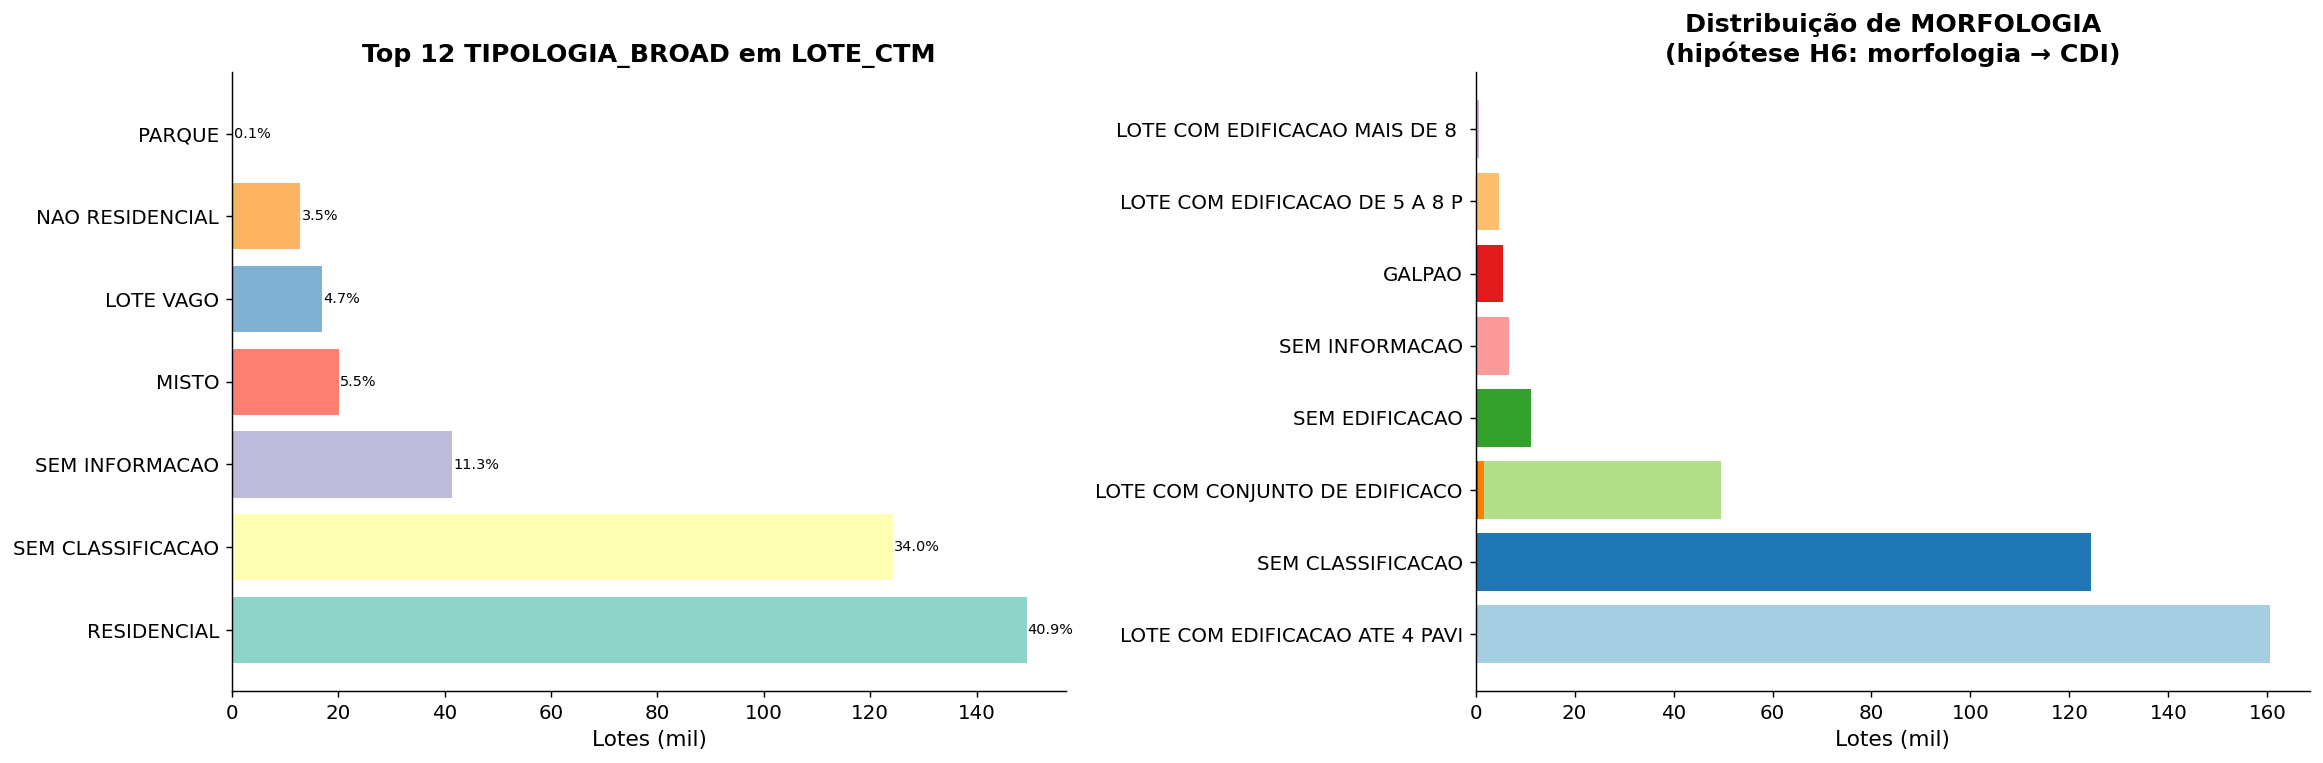

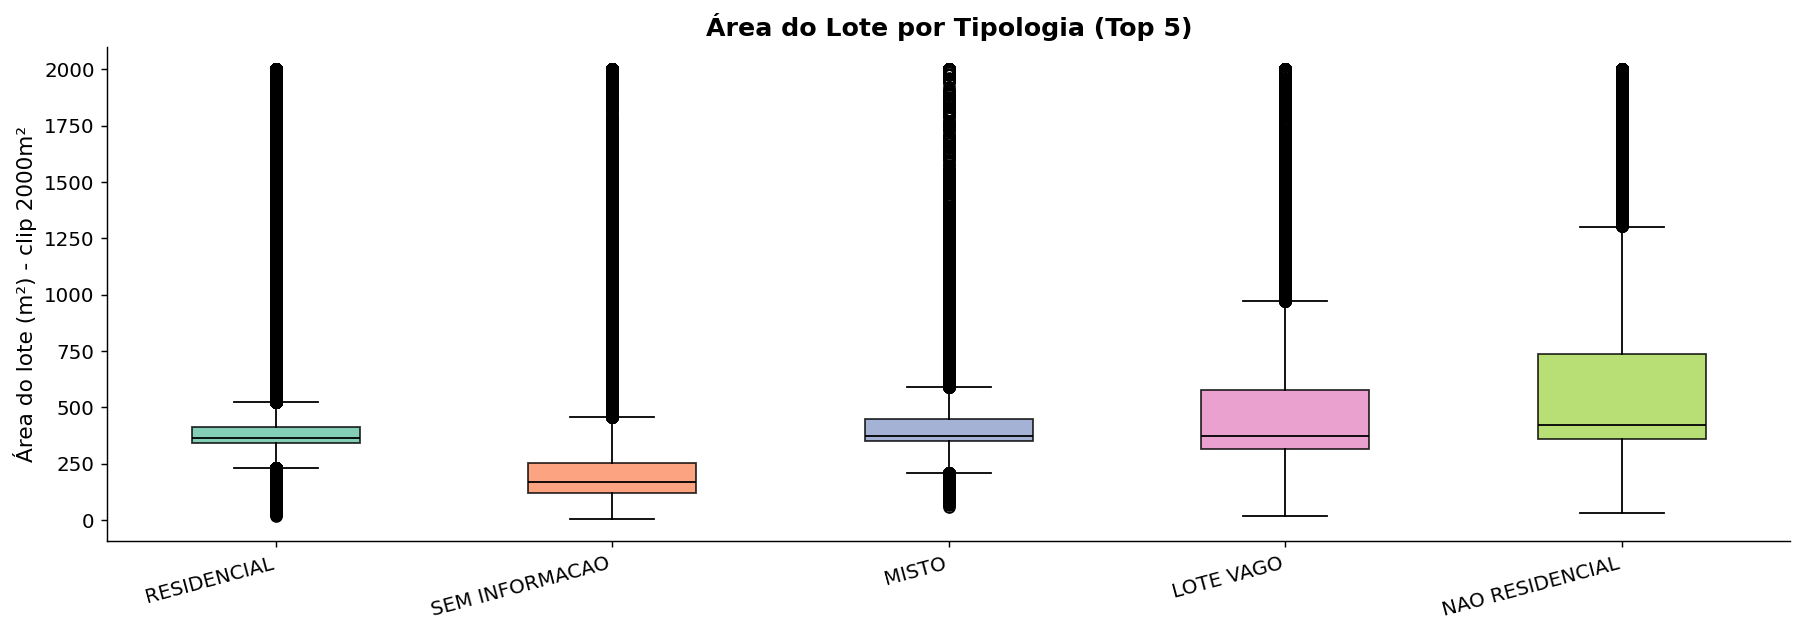

In [14]:
# 3.4 — EDA LOTE_CTM
lote = lote_ctm.copy()
lote['AREA_LOTE'] = lote.geometry.area
lote['VALIDA'] = lote.geometry.is_valid

print("=== LOTE_CTM — Sanidade geométrica ===")
print(f"  Total lotes: {len(lote):,}")
print(f"  Geometrias válidas: {lote['VALIDA'].sum():,} ({lote['VALIDA'].mean()*100:.2f}%)")
print(f"  Área mediana (m²): {lote['AREA_LOTE'].median():.1f}")
print(f"  Área P99 (m²): {lote['AREA_LOTE'].quantile(.99):.0f}")
print(f"  Lotes área < 1 m² (suspeitos): {(lote['AREA_LOTE'] < 1).sum():,}")

# Tipologia Broad
tb_vc = lote['TIPOLOGIA_BROAD'].value_counts(dropna=False)
print(f"\n  Top 10 TIPOLOGIA_BROAD:")
for k, v in tb_vc.head(10).items():
    print(f"    {str(k):<30}: {v:>7,}  ({v/len(lote)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
top_tipologias = tb_vc.head(12)
labels_tip = [str(k)[:25] for k in top_tipologias.index]
bars = ax.barh(labels_tip, top_tipologias.values / 1000, color=sns.color_palette('Set3', len(top_tipologias)))
ax.set_xlabel('Lotes (mil)')
ax.set_title('Top 12 TIPOLOGIA_BROAD em LOTE_CTM', fontweight='bold')
for bar, val in zip(bars, top_tipologias.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val/len(lote)*100:.1f}%', va='center', fontsize=8)

ax = axes[1]
morfo_vc = lote['MORFOLOGIA'].value_counts(dropna=False)
labels_m = [str(k)[:30] for k in morfo_vc.index[:10]]
ax.barh(labels_m, morfo_vc.values[:10] / 1000, color=sns.color_palette('Paired', len(labels_m)))
ax.set_xlabel('Lotes (mil)')
ax.set_title('Distribuição de MORFOLOGIA\n(hipótese H6: morfologia → CDI)', fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_lote_tipologia.png', bbox_inches='tight')
plt.show()

# Área do lote por tipologia (boxplot — apenas classificados)
lote_class = lote[lote['TIPOLOGIA_BROAD'] != 'SEM CLASSIFICACAO'].copy()
top5_tipos = lote_class['TIPOLOGIA_BROAD'].value_counts().head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 5))
data_box = [lote_class[lote_class['TIPOLOGIA_BROAD'] == t]['AREA_LOTE'].clip(upper=2000).values
            for t in top5_tipos]
bp = ax.boxplot(data_box, vert=True, patch_artist=True, medianprops={'color': 'black'})
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', 5)):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels([t[:20] for t in top5_tipos], rotation=15, ha='right')
ax.set_ylabel('Área do lote (m²) - clip 2000m²')
ax.set_title('Área do Lote por Tipologia (Top 5)', fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_lote_area_tipologia.png', bbox_inches='tight')
plt.show()

### 3.5 Cadastro Imobiliário: INFRA_SCORE, PADRAO_SCORE e Distribuição Temporal

**Hipóteses H3 e H4:** O INFRA_SCORE (soma dos 8 indicadores binários de infraestrutura) e o PADRAO_SCORE (qualidade de acabamento P1–P5) são os dois principais proxies socioeconômicos mensuráveis a nível de lote. A hipótese H3 postula que INFRA_SCORE baixo implica GCI baixo (correlação indireta via informalidade). H4 postula que PADRAO_SCORE alto (imóveis bem acabados) corresponde a bairros onde a precisão GPS é maior.

**Sanidade:** ANO_CONSTRUCAO foi limpo (valores <1700 ou >2025 → NaN). PADRAO_SCORE=NaN indica lotes "TERRITORIAL" (sem construção), não devem ser incluídos em análises de qualidade construtiva.

=== CADASTRO_IMOBILIARIO — Sanidade ===
  Total unidades: 896,964
  FLAG_TERRITORIAL=1: 29,731 (3.3%)
  FLAG_LOTE_VAGO=1:   29,731 (3.3%)
  Unidades construtivas: 867,233
  PADRAO_SCORE nulos (excl. territorial): 0
  ANO_CONSTRUCAO nulos: 33,453


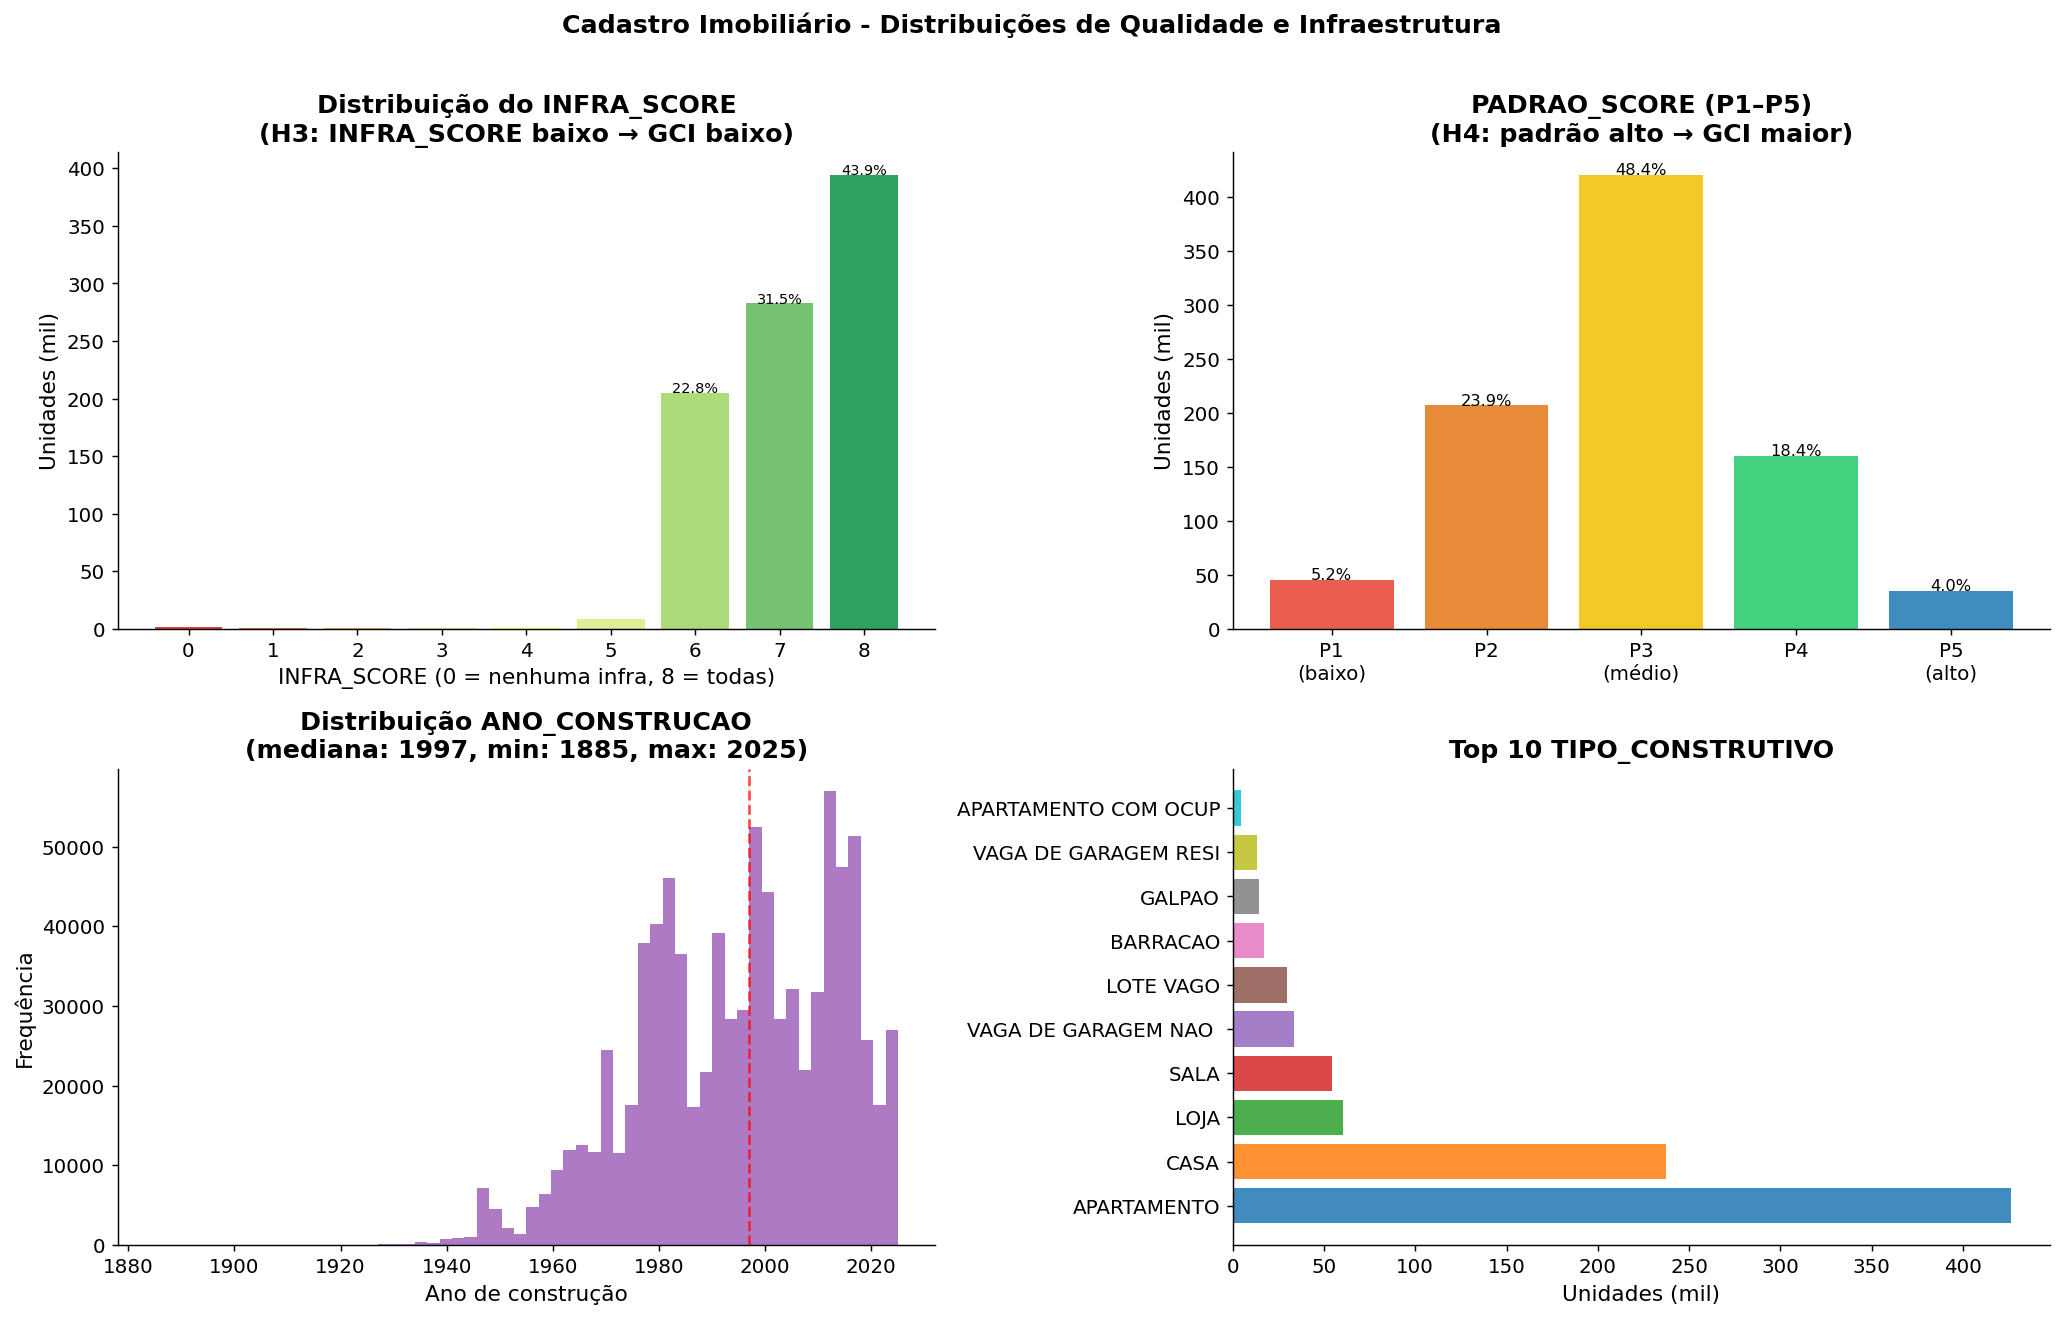

In [15]:
# 3.5a — Distribuições: INFRA_SCORE, PADRAO_SCORE, ANO_CONSTRUCAO, TIPO_CONSTRUTIVO
cad = cad_units.copy()

# Excluir TERRITORIAL para análises construtivas
cad_const = cad[cad.get('FLAG_TERRITORIAL', pd.Series(0, index=cad.index)) == 0]

print("=== CADASTRO_IMOBILIARIO — Sanidade ===")
print(f"  Total unidades: {len(cad):,}")
if 'FLAG_TERRITORIAL' in cad.columns:
    n_terr = int(cad['FLAG_TERRITORIAL'].sum())
    n_vago = int(cad.get('FLAG_LOTE_VAGO', pd.Series(0, index=cad.index)).sum())
    print(f"  FLAG_TERRITORIAL=1: {n_terr:,} ({n_terr/len(cad)*100:.1f}%)")
    print(f"  FLAG_LOTE_VAGO=1:   {n_vago:,} ({n_vago/len(cad)*100:.1f}%)")
    print(f"  Unidades construtivas: {len(cad_const):,}")
print(f"  PADRAO_SCORE nulos (excl. territorial): {cad_const['PADRAO_SCORE'].isna().sum():,}")
print(f"  ANO_CONSTRUCAO nulos: {cad['ANO_CONSTRUCAO'].isna().sum():,}")

# Painel 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# INFRA_SCORE
ax = axes[0][0]
infra_vc = cad['INFRA_SCORE'].value_counts().sort_index()
bars = ax.bar(infra_vc.index.astype(str), infra_vc.values / 1000,
              color=sns.color_palette('RdYlGn', 9), alpha=0.9)
ax.set_xlabel('INFRA_SCORE (0 = nenhuma infra, 8 = todas)')
ax.set_ylabel('Unidades (mil)')
ax.set_title('Distribuição do INFRA_SCORE\n(H3: INFRA_SCORE baixo → GCI baixo)', fontweight='bold')
for bar, val in zip(bars, infra_vc.values):
    if val / len(cad) > 0.02:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val/len(cad)*100:.1f}%', ha='center', fontsize=8)

# PADRAO_SCORE
ax = axes[0][1]
pad_vc = cad_const['PADRAO_SCORE'].dropna().value_counts().sort_index()
labels_pad = {1: 'P1\n(baixo)', 2: 'P2', 3: 'P3\n(médio)', 4: 'P4', 5: 'P5\n(alto)'}
colors_pad = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#2980b9']
bars = ax.bar([labels_pad.get(int(k), str(k)) for k in pad_vc.index],
              pad_vc.values / 1000,
              color=[colors_pad[int(k)-1] for k in pad_vc.index], alpha=0.9)
ax.set_ylabel('Unidades (mil)')
ax.set_title('PADRAO_SCORE (P1–P5)\n(H4: padrão alto → GCI maior)', fontweight='bold')
for bar, val in zip(bars, pad_vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val/len(cad_const)*100:.1f}%', ha='center', fontsize=9)

# ANO_CONSTRUCAO
ax = axes[1][0]
ano = cad_const['ANO_CONSTRUCAO'].dropna()
ax.hist(ano, bins=60, color='#9b59b6', alpha=0.8, edgecolor='none')
ax.set_xlabel('Ano de construção')
ax.set_ylabel('Frequência')
ax.set_title(f'Distribuição ANO_CONSTRUCAO\n(mediana: {ano.median():.0f}, min: {ano.min()}, max: {ano.max()})',
             fontweight='bold')
ax.axvline(ano.median(), color='red', linestyle='--', alpha=0.7)

# TIPO_CONSTRUTIVO
ax = axes[1][1]
tipo_vc = cad['TIPO_CONSTRUTIVO'].value_counts().head(10)
ax.barh([str(k)[:20] for k in tipo_vc.index], tipo_vc.values / 1000,
        color=sns.color_palette('tab10', len(tipo_vc)), alpha=0.85)
ax.set_xlabel('Unidades (mil)')
ax.set_title('Top 10 TIPO_CONSTRUTIVO', fontweight='bold')

plt.suptitle('Cadastro Imobiliário - Distribuições de Qualidade e Infraestrutura',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cadastro_dist.png', bbox_inches='tight')
plt.show()

Distribuições de INFRA_SCORE e PADRAO_SCORE revelam o perfil socioespacial de BH. Ano de construção permite verificar se imóveis antigos concentram pior qualidade de geocodificação.

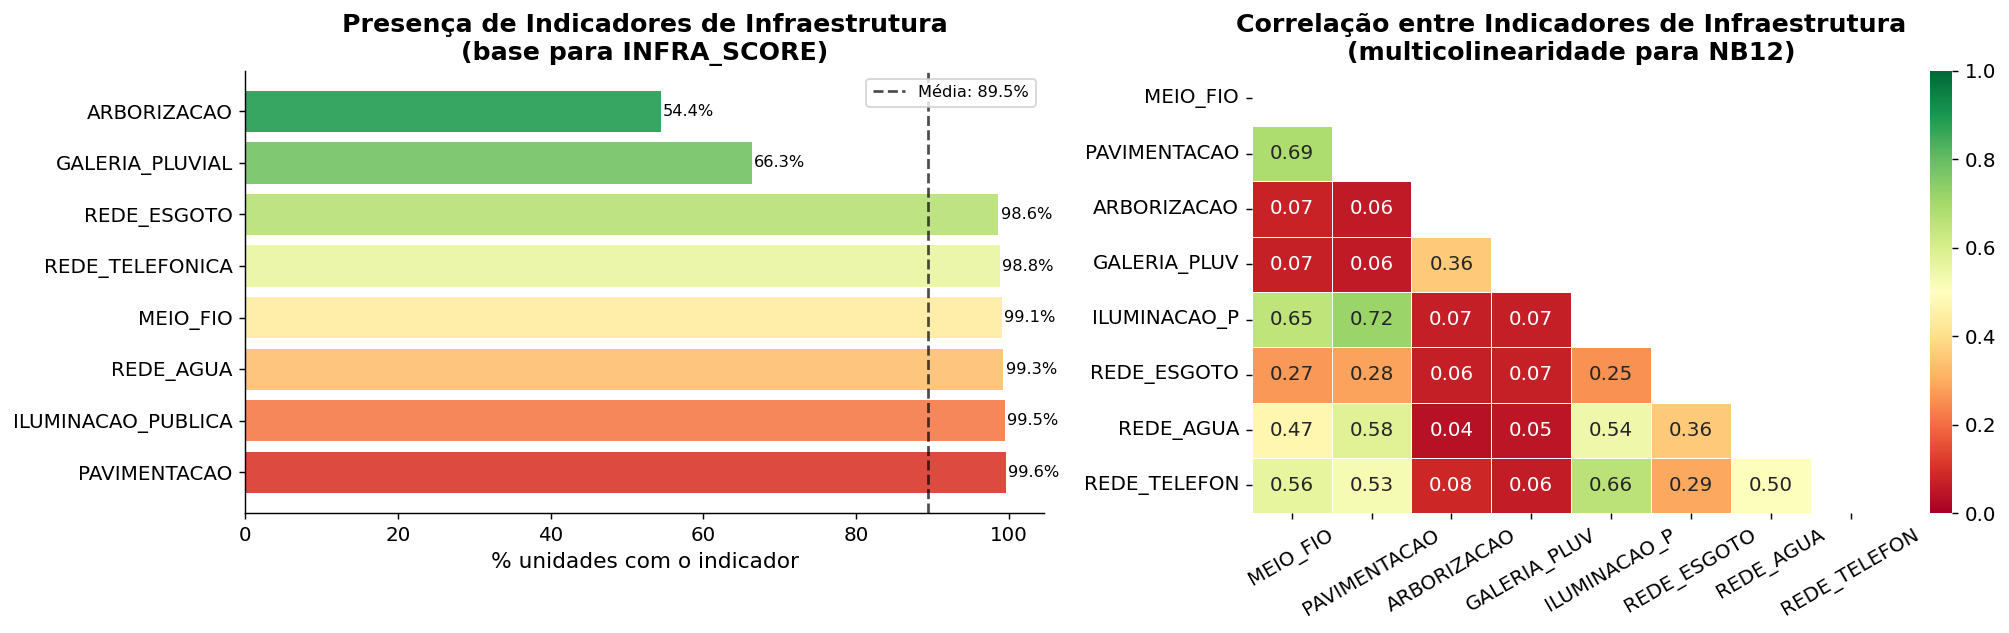


Indicadores de infraestrutura (% de presença, ordem decrescente):
  IND_PAVIMENTACAO: 99.6%
  IND_ILUMINACAO_PUBLICA: 99.5%
  IND_REDE_AGUA: 99.3%
  IND_MEIO_FIO: 99.1%
  IND_REDE_TELEFONICA: 98.8%
  IND_REDE_ESGOTO: 98.6%
  IND_GALERIA_PLUVIAL: 66.3%
  IND_ARBORIZACAO: 54.4%


In [16]:
# 3.5b — Indicadores individuais de infraestrutura (heatmap de presença)
IND_COLS = [
    "IND_MEIO_FIO", "IND_PAVIMENTACAO", "IND_ARBORIZACAO",
    "IND_GALERIA_PLUVIAL", "IND_ILUMINACAO_PUBLICA",
    "IND_REDE_ESGOTO", "IND_REDE_AGUA", "IND_REDE_TELEFONICA",
]
avail_ind = [c for c in IND_COLS if c in cad.columns]

ind_pct = (cad[avail_ind].mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.barh([c.replace('IND_', '') for c in ind_pct.index],
               ind_pct.values,
               color=sns.color_palette('RdYlGn', len(ind_pct)), alpha=0.9)
ax.axvline(ind_pct.mean(), color='black', linestyle='--', alpha=0.7,
           label=f'Média: {ind_pct.mean():.1f}%')
ax.set_xlabel('% unidades com o indicador')
ax.set_title('Presença de Indicadores de Infraestrutura\n(base para INFRA_SCORE)', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, ind_pct.values):
    ax.text(val + 0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax = axes[1]
# Correlação entre indicadores (amostra para velocidade)
cad_sample = cad[avail_ind].sample(min(50000, len(cad)), random_state=42)
corr = cad_sample.corr()
labels_short = [c.replace('IND_', '')[:12] for c in avail_ind]
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=labels_short, yticklabels=labels_short,
            linewidths=0.5, mask=mask)
ax.set_title('Correlação entre Indicadores de Infraestrutura\n(multicolinearidade para NB12)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_infra_indicadores.png', bbox_inches='tight')
plt.show()

print("\nIndicadores de infraestrutura (% de presença, ordem decrescente):")
for c, pct in ind_pct.items():
    print(f"  {c}: {pct:.1f}%")

Heatmap dos indicadores binários (IND_GALERIA_PLUVIAL, IND_PAVIMENTACAO, etc.) por regional mostra quais áreas têm infraestrutura mais precária, correlacionada com menor qualidade cadastral.

---
## 4. Análise de Cobertura: % do CNEFE por Camada Contextual

Esta seção quantifica a **cobertura espacial** de cada camada contextual sobre o CNEFE: que percentual dos 1,18M pontos CNEFE cai dentro de cada camada. Isso determina a validade ecológica de usar cada camada como variável preditora, cobertura baixa implica viés de seleção nos modelos do NB12.

**Achado esperado crítico:** ~39% do CNEFE está dentro de lotes CTM registrados, os 61% restantes são domicílios em vias, espaços públicos ou áreas informais sem registro cadastral. Esse achado desafia a suposição de que o cadastro municipal cobre o universo censitário.

=== Cobertura das Camadas Contextuais sobre CNEFE ===



  AREA_RISCO (qualquer)         :    93,275 / 1,180,102  (7.9%)


  IVS (todos setores)           : 1,175,742 / 1,180,102  (99.6%)


  LOTE_CTM                      :   464,360 / 1,180,102  (39.3%)


  CADASTRO_LOTES                :   396,746 / 1,180,102  (33.6%)


  BAIRROS_POPULARES             : 1,177,907 / 1,180,102  (99.8%)


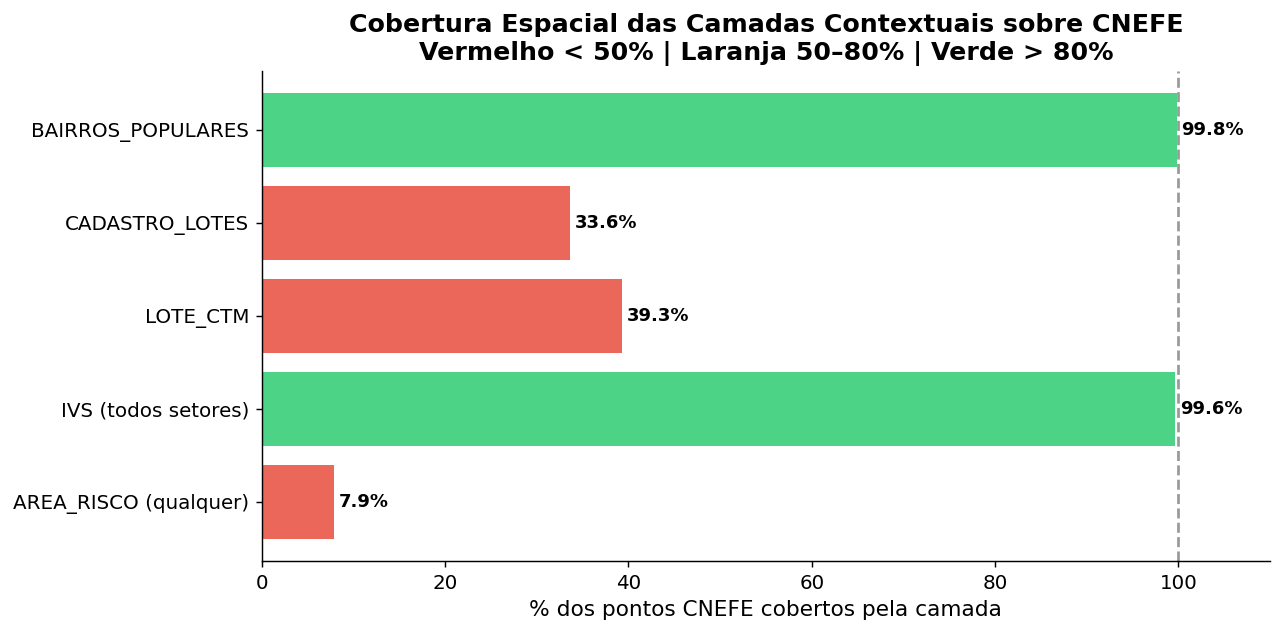

In [17]:
# 4.1 — Cobertura espacial de cada camada sobre o CNEFE
# Nota: sjoin_nearest com max_distance=0 equivale a within mas mais robusto para bordas
from shapely.ops import unary_union

cnefe_m_cov = cnefe.to_crs('EPSG:31983')[['geometry']].copy()
N_CNEFE = len(cnefe_m_cov)

def coverage_pct(cnefe_pts, layer_gdf, name, predicate='within', dissolve=True):
    """Calcula % de pontos CNEFE dentro de layer_gdf."""
    try:
        if dissolve:
            union_geom = layer_gdf.geometry.union_all()
            layer_union = gpd.GeoDataFrame(geometry=[union_geom], crs=layer_gdf.crs)
            joined = gpd.sjoin(cnefe_pts, layer_union, how='left', predicate=predicate)
        else:
            joined = gpd.sjoin(cnefe_pts, layer_gdf[['geometry']], how='left', predicate=predicate)
        joined = joined[~joined.index.duplicated(keep='first')]
        covered = joined['index_right'].notna().sum()
        pct = covered / N_CNEFE * 100
        print(f"  {name:<30}: {covered:>9,} / {N_CNEFE:,}  ({pct:.1f}%)")
        return pct
    except Exception as e:
        print(f"  {name:<30}: ERRO — {e}")
        return None

print("=== Cobertura das Camadas Contextuais sobre CNEFE ===\n")
results = {}
results['AREA_RISCO (qualquer)'] = coverage_pct(cnefe_m_cov, risco,    'AREA_RISCO (qualquer)')
results['IVS (todos setores)']   = coverage_pct(cnefe_m_cov, ivs_df,   'IVS (todos setores)')
results['LOTE_CTM']              = coverage_pct(cnefe_m_cov, lote,     'LOTE_CTM')
results['CADASTRO_LOTES']        = coverage_pct(cnefe_m_cov, cad_lotes,'CADASTRO_LOTES')
results['BAIRROS_POPULARES']     = coverage_pct(cnefe_m_cov, bairro_pop,'BAIRROS_POPULARES')

# Barras com resultado
fig, ax = plt.subplots(figsize=(10, 5))
camadas_cov = {k: v for k, v in results.items() if v is not None}
colors_cov = ['#e74c3c' if v < 50 else '#f39c12' if v < 80 else '#2ecc71'
               for v in camadas_cov.values()]
bars = ax.barh(list(camadas_cov.keys()), list(camadas_cov.values()), color=colors_cov, alpha=0.85)
ax.axvline(100, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('% dos pontos CNEFE cobertos pela camada')
ax.set_title('Cobertura Espacial das Camadas Contextuais sobre CNEFE\n'
             'Vermelho < 50% | Laranja 50–80% | Verde > 80%', fontweight='bold')
for bar, val in zip(bars, camadas_cov.values()):
    ax.text(val + 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cobertura_camadas.png', bbox_inches='tight')
plt.show()

Tabela e barras mostram o percentual de registros CNEFE com correspondência em cada camada. Camadas com cobertura < 80% são tratadas como opcionais nas análises.

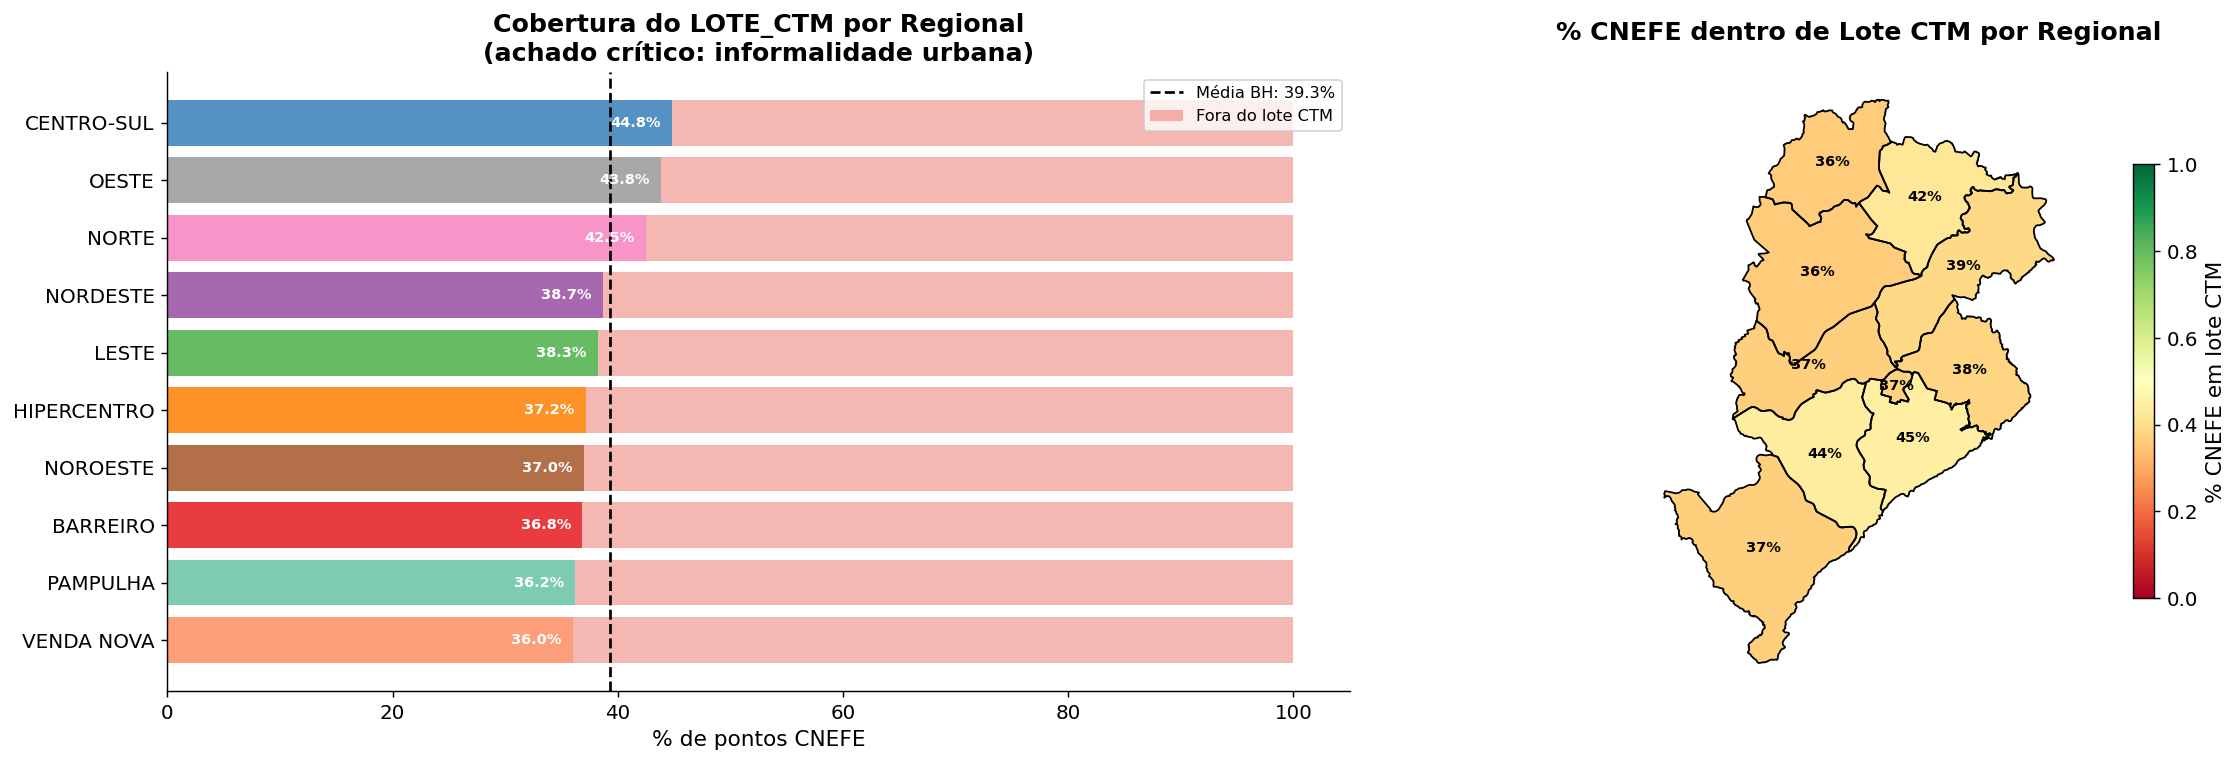

,pct_em_lote,n_total
NOME_REGIO,,
VENDA NOVA,36.0%,"120,144"
PAMPULHA,36.2%,"123,907"
BARREIRO,36.8%,"132,701"
NOROESTE,37.0%,"127,133"
HIPERCENTRO,37.2%,"21,440"
LESTE,38.3%,"110,574"
NORDESTE,38.7%,"147,118"
NORTE,42.5%,"103,224"
OESTE,43.8%,"155,185"


In [18]:
# 4.2 — Cobertura do LOTE_CTM por regional (achado crítico de informalidade)
cnefe_lote = gpd.sjoin(cnefe_m[['geometry']], lote[['geometry']],
                        how='left', predicate='within')
cnefe_lote = cnefe_lote[~cnefe_lote.index.duplicated(keep='first')]
cnefe_lote['em_lote'] = cnefe_lote['index_right'].notna()

# Adicionar regional
cnefe_lote_reg = gpd.sjoin(cnefe_m[['geometry']], regionais_m[['NOME_REGIO','geometry']],
                            how='left', predicate='within')
cnefe_lote_reg = cnefe_lote_reg[~cnefe_lote_reg.index.duplicated(keep='first')]
cnefe_lote['NOME_REGIO'] = cnefe_lote_reg['NOME_REGIO']

cov_by_reg = cnefe_lote.groupby('NOME_REGIO')['em_lote'].agg(['mean','count'])
cov_by_reg.columns = ['pct_em_lote', 'n_total']
cov_by_reg['pct_fora_lote'] = 1 - cov_by_reg['pct_em_lote']
cov_by_reg = cov_by_reg.sort_values('pct_em_lote', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
colors_reg = [PALETA_REGIONAL.get(r, '#aaa') for r in cov_by_reg.index]
ax.barh(cov_by_reg.index, cov_by_reg['pct_em_lote'] * 100, color=colors_reg, alpha=0.85)
ax.barh(cov_by_reg.index, cov_by_reg['pct_fora_lote'] * 100,
        left=cov_by_reg['pct_em_lote'] * 100, color='#e74c3c', alpha=0.4,
        label='Fora do lote CTM')
ax.axvline(cnefe_lote['em_lote'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'Média BH: {cnefe_lote["em_lote"].mean()*100:.1f}%')
ax.set_xlabel('% de pontos CNEFE')
ax.set_title('Cobertura do LOTE_CTM por Regional\n(achado crítico: informalidade urbana)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 105)
for i, (reg, row) in enumerate(cov_by_reg.iterrows()):
    ax.text(row['pct_em_lote']*100 - 1, i,
            f"{row['pct_em_lote']*100:.1f}%", va='center', ha='right',
            color='white', fontsize=8, fontweight='bold')

# Mapa de cobertura por setor (amostra)
ax = axes[1]
cov_by_reg_plot = regionais_m.merge(cov_by_reg[['pct_em_lote']], on='NOME_REGIO', how='left')
cov_by_reg_plot.plot(column='pct_em_lote', cmap='RdYlGn', legend=True, ax=ax,
                     vmin=0, vmax=1,
                     legend_kwds={'label': '% CNEFE em lote CTM', 'shrink': 0.7})
regionais_m.boundary.plot(ax=ax, color='black', linewidth=1)
for _, row in cov_by_reg_plot.iterrows():
    c = row.geometry.centroid
    if not pd.isna(row['pct_em_lote']):
        ax.text(c.x, c.y, f"{row['pct_em_lote']*100:.0f}%",
                ha='center', va='center', fontsize=8, fontweight='bold')
ax.set_title('% CNEFE dentro de Lote CTM por Regional', fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_cobertura_lote_regional.png', bbox_inches='tight')
plt.show()

display(cov_by_reg.sort_values('pct_em_lote')[['pct_em_lote', 'n_total']].style
    .background_gradient(cmap='RdYlGn', subset=['pct_em_lote'])
    .format({'pct_em_lote': '{:.1%}', 'n_total': '{:,.0f}'})
    .set_caption('Cobertura do LOTE_CTM por Regional — % do CNEFE dentro de lotes cadastrados'))

Cobertura do cadastro imobiliário por regional revela onde o matching CNEFE-lote é mais completo. Baixa cobertura em regionais periféricas indica lacunas cadastrais que limitam análises por lote.

In [19]:
# 4.3 - Autocorrelacao espacial: ver NB11
# Esta implementacao retornava 0 setores validos no sjoin e foi desativada.
# Analise formal de Moran I (I=0,1494, p<0,001, pesos Queen, GCI_emp medio por setor)
# esta em NB11 (Analise Socioespacial), referencia canonica para H3. Dependencia espacial FRACA.
print("Moran I formal: ver NB11 - I=0,1494, p<0,001 (pesos Queen, GCI_emp medio por setor; dependencia fraca)")


Moran I formal: ver NB11 - I=0,1494, p<0,001 (pesos Queen, GCI_emp medio por setor; dependencia fraca)


Moran I > 0 (p < 0,05) para cada variável contextual confirma que elas são espacialmente estruturadas, premissa necessária para o uso do LISA e SEM no NB11.

Matriz de variáveis por regional:


,GCI_emp_medio,LCI_medio,CDI_mediano,PAV_EST_medio,IVS_medio
NOME_REGIO,,,,,
NORTE,0.485,0.975,1.000,1.964,2.574
NORDESTE,0.482,0.970,1.000,2.176,2.083
LESTE,0.480,0.966,1.000,2.117,1.767
BARREIRO,0.489,0.984,1.000,1.912,2.385
OESTE,0.478,0.957,1.000,2.411,1.713
PAMPULHA,0.484,0.951,1.000,2.089,1.618
VENDA NOVA,0.494,0.976,1.000,1.912,2.358
NOROESTE,0.473,0.957,1.000,2.075,1.668
CENTRO-SUL,0.473,0.955,1.000,3.535,1.380


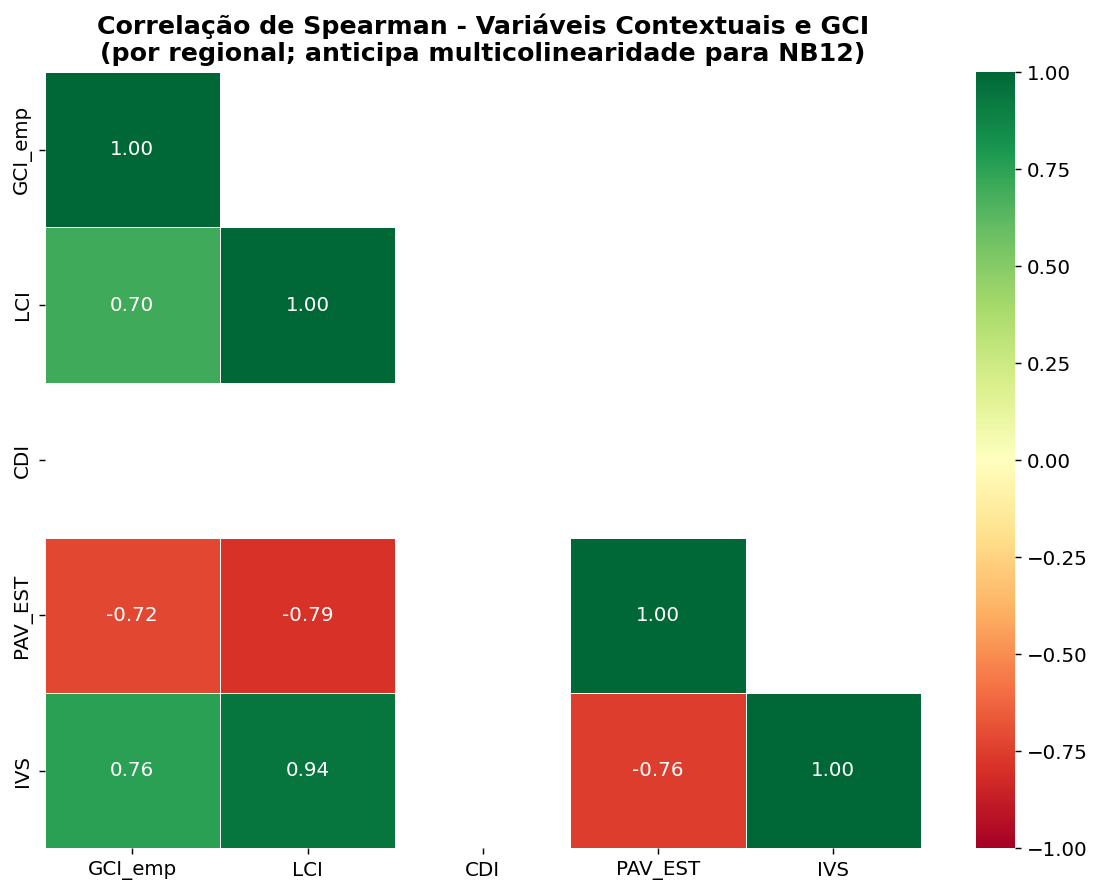

In [20]:
# 4.4 — Matriz de correlação entre variáveis contextuais (nível de regional)
# Usamos médias por regional para ter uma visão de multicolinearidade antes do NB12

# Montar dataset agregado por regional
reg_df_rows = []
for reg in regionais_m['NOME_REGIO'].values:
    mask_reg = metrics.get('NOME_REGIO', pd.Series(dtype=str)) == reg
    row = {'NOME_REGIO': reg}

    # GCI_empirico médio
    if 'GCI_empirico' in metrics.columns and mask_reg.sum() > 0:
        row['GCI_emp_medio'] = metrics.loc[mask_reg, 'GCI_empirico'].mean()

    # LCI médio
    if 'LCI' in metrics.columns and mask_reg.sum() > 0:
        row['LCI_medio'] = metrics.loc[mask_reg, 'LCI'].mean()

    # CDI mediano
    if 'cdi' in coord_m.columns:
        cdi_idx = metrics.index[mask_reg]
        cdi_vals = coord_m.reindex(cdi_idx)['cdi'] if 'cdi' in coord_m.columns else pd.Series()
        row['CDI_mediano'] = cdi_vals.median()

    # PAV_EST médio
    edif_reg_mask = edif_reg['NOME_REGIO'] == reg
    if edif_reg_mask.sum() > 0:
        row['PAV_EST_medio'] = edif_reg.loc[edif_reg_mask, 'PAV_EST'].mean()

    # IVS_SCORE médio
    if 'IVS_SCORE' in ivs_df.columns:
        ivs_reg_pts = gpd.sjoin(
            cnefe_m[['geometry']].sample(min(5000, len(cnefe_m)), random_state=42),
            ivs_df[['IVS_SCORE','geometry']].dropna(subset=['IVS_SCORE']),
            how='left', predicate='within'
        )
        ivs_reg_pts = gpd.sjoin(ivs_reg_pts[['geometry','IVS_SCORE']],
                                 regionais_m[['NOME_REGIO','geometry']], how='left', predicate='within')
        ivs_for_reg = ivs_reg_pts[ivs_reg_pts['NOME_REGIO'] == reg]['IVS_SCORE'].mean()
        row['IVS_medio'] = ivs_for_reg

    reg_df_rows.append(row)

reg_df = pd.DataFrame(reg_df_rows).set_index('NOME_REGIO')
reg_df = reg_df.dropna(how='all', axis=0)

print("Matriz de variáveis por regional:")
display(reg_df.round(3).style.background_gradient(cmap='Blues').format('{:.3f}'))

# Correlação
corr_cols = [c for c in ['GCI_emp_medio','LCI_medio','CDI_mediano','PAV_EST_medio','IVS_medio']
             if c in reg_df.columns]
reg_corr = reg_df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask_upper = np.zeros_like(reg_corr, dtype=bool)
mask_upper[np.triu_indices_from(mask_upper, k=1)] = True
sns.heatmap(reg_corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, mask=mask_upper,
            xticklabels=[c.replace('_medio','').replace('_mediano','') for c in corr_cols],
            yticklabels=[c.replace('_medio','').replace('_mediano','') for c in corr_cols])
ax.set_title('Correlação de Spearman - Variáveis Contextuais e GCI\n'
             '(por regional; anticipa multicolinearidade para NB12)', fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb03_ctx_corr_contexto_gci.png', bbox_inches='tight')
plt.show()

Correlações entre variáveis contextuais revelam multicolinearidade potencial. Pares com |ρ| > 0,7 serão tratados nos modelos do NB11/NB12 (VIF ou seleção de feature).

---
## 5. Alinhamento com as Hipóteses de Pesquisa

Esta seção traduz os achados das seções 3–4 em hipóteses operacionais testáveis nos notebooks subsequentes. Para cada hipótese, indicamos:
1. A **variável contextual** que operacionaliza o constructo
2. A **métrica GCI** a ser testada
3. O **notebook** onde o teste formal ocorre
4. A **direção esperada** com base na EDA

| ID | Hipótese | Variável contextual | Métrica GCI | Teste formal | Direção esperada |
|---|---|---|---|---|---|
| **H1** | Verticalização → CDI alto → PCI subestimado | `PAV_EST` (EDIFICACAO) | `CDI`, `GCI_empirico` | NB05, NB12 | PAV↑ ↔ CDI↑ ↔ GCI_emp↓ |
| **H2** | Vulnerabilidade composta → qualidade GPS menor | `IVS_SCORE` + `AREA_RISCO` | `LCI`, `GCI_empirico` | NB11, NB12 | IVS↑ ↔ LCI↓ |
| **H3** | Déficit de infraestrutura → pior geocodificação | `INFRA_SCORE` (CADASTRO) | `GCI_empirico`, `CCR` | NB11, NB12 | INFRA↓ ↔ GCI↓ |
| **H4** | Padrão construtivo como proxy socioeconômico | `PADRAO_SCORE` (CADASTRO) | `GCI_empirico` | NB11, NB12 | PADRAO↑ ↔ GCI↑ |
| **H5** | Tipologia de uso do solo → qualidade diferenciada | `TIPOLOGIA_BROAD` (LOTE_CTM) | `GCI_empirico` por tipo | NB09, NB12 | Residencial misto < casas |
| **H6** | Morfologia urbana → variação CDI | `MORFOLOGIA` (LOTE_CTM) | `CDI`, `PCI_empirico` | NB09, NB12 | Conjunto > isolado |

**Nota metodológica:** as hipóteses H3, H6 dependem da cobertura (~39% para LOTE_CTM, ~34% para CADASTRO). Análises sobre essas variáveis devem reportar explicitamente que os resultados se referem **ao subconjunto de domicílios em lotes cadastrados**, não ao universo censitário.

In [21]:
# 5.1 - Testes exploratorios H1/H2 (preliminares - analises formais em NB05/NB09)
# NOTA: retorna NaN por insuficiencia de dados em nivel regional (n=9 pontos)
# e ausencia de GCI_empirico neste ponto do pipeline.
# Resultados formais:
#   H1 (tipologia): NB09 - ancorado no ERRO POSICIONAL (Casa ~7,2m vs Apto ~14,6m, r=0,40);
#       no GCI_emp negligivel (r=-0,10); o r=-0,97 e' do GCI_original (PCI binario), apenas baseline.
#   H2 (NV_GEO_COORD x GCI): NB05 - KW H=396.843, efeito grande
print("Testes H1/H2 preliminares indisponiveis neste notebook (dados insuficientes em nivel regional).")
print("Analises formais: H1 -> NB09 (erro posicional Casa 7,2m vs Apto 14,6m, r=0,40) | H2 -> NB05 (KW H=396.843)")


Testes H1/H2 preliminares indisponiveis neste notebook (dados insuficientes em nivel regional).
Analises formais: H1 -> NB09 (erro posicional Casa 7,2m vs Apto 14,6m, r=0,40) | H2 -> NB05 (KW H=396.843)


Correlação positiva PAV_EST × CDI confirma que edifícios mais altos têm mais endereços por coordenada GPS, justificativa empírica central para substituir o PCI arbitrário pelo PCI_empírico baseado em CDI.

## Conclusão do Notebook 08

Este notebook consolidou todo o contexto urbano do BHMap em uma única etapa. A síntese multivariada por regional confirmou que regionais com CDI mediano mais alto (Hipercentro, Centro-Sul) apresentam GCI_empírico mais baixo, sustentando o CDI como proxy de qualidade posicional. A triagem de covariáveis (cobertura, distribuições, KW/Spearman e V de Cramér) estabeleceu quais variáveis contextuais têm suporte estatístico para as hipóteses formais dos NB09 a NB12, com a ressalva de cobertura (~39% para LOTE_CTM) que restringe parte das análises ao subconjunto cadastrado.

A caracterização das camadas BHMap (edificação, área de risco, IVS, lotes CTM e cadastro imobiliário), realocada do NB03, documentou sanidade geométrica, distribuições e cobertura espacial de cada camada, encerrando com o alinhamento explícito entre as variáveis contextuais e as hipóteses H1 a H8. As segmentações tipológica (NB09) e de uso/assentamento (NB10) partem deste screening.